# CPE15 MIDTERM PROJECT - Cleaning Notebook
---
## Part I: Field Data Collection, Validation, Cleaning, and Documentation
---
### BSCPE 3GF
### Submitted on: Oct 11, 2026




In [977]:
import numpy as np
import pandas as pd
import geopandas as gpd
import glob
import matplotlib.pyplot as plt
import re

## Function Definitions

In [978]:
columns = ['Time', 'ID',
      'feature_id', 'name', 'category', 'subcategory',
      'street', 'barangay', 'Latitude', 'Longitude',
      'location_description', 'operating_status', 'opening_hours',
      'contact_info', 'collector', 'date_collected',
      'remarks', 'verified', 'Horizontal Accuracy',
  ]

def read_csv_files(x):

  df = pd.read_csv(x, usecols = columns, dtype=str)
  df = df[columns]

  return df

In [979]:
def clean_mixed_dates(df):

    df['date_collected'] = (
        df['date_collected']
        .astype('string')
        .str.strip()
        .str.replace('_', '-', regex=False)
    )

    df['date_collected'] = pd.to_datetime(
        df['date_collected'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    return df

In [980]:
def clean_whitespace(df):

  for column in columns:
      df[column] = (
          df[column]
          .astype('string')
          .str.strip()                 # removes spaces at beginning/end
          .str.replace(r'\s+', ' ', regex=True)  # removes extra spaces between words
      )

  return df

In [981]:
def format_collector(collector_name):
  if pd.isna(collector_name):
    return None

  if ',' in collector_name:
    parts = str(collector_name).split(',')
    last_name = ' '.join(parts[0].split()).title()
    first_and_mi = ' '.join(' '.join(parts[1:]).split()).title()

    return f'{last_name}, {first_and_mi}'

  parts = str(collector_name).split()
  if len(parts) > 1:
    last_name = parts[-1].title()
    first_and_mi = ' '.join(parts[:-1]).title()

    return f'{last_name}, {first_and_mi}'

  return str(collector_name).title()

# collector_name = 'LIBAO, Ried Carlo C.' # Example Case
# print(format_name(collector_name))



In [982]:
def clean_street_names(street):
  if not isinstance(street, str):
    return street

  titled_name = street.title()

  return street_map.get(titled_name, titled_name)

In [983]:
def clean_contact_info(contact):
  if contact.isna(contact):
    return 'Not Provided'

  contact = str(contact).split('/')[0].strip()
  df['contact_info'] = df['contact_info'].astype(str)

  has_letters = df['contact_info'].str.contains(r'[a-zA-Z]', regex=True)

  df['contact_info'] = df['contact_info'].where(~has_letters, '').str.replace(r'\D', '', regex=True)

  if len(contact) == 10 and contact.startswith('9'):
    return '0' + contact

  if len(contact) == 7 and contact.startswith('5'):
    return '(042) ' + contact

  return contact



In [984]:
def verify_collector(df):
  df['correct_format'] = df['collector'].str.match(r"^[^,]+,\s*[^,]+$", na=False)

  print(df['correct_format'].value_counts())
  incorrect_df = df[~df['correct_format']]

  # Print all rows with incorrect formatting
  print(incorrect_df[['collector', 'correct_format']].to_string())

## Importing the raw datas (csv files from Google Drive)

In [985]:
# uc?export=download&id=

raw_datasets = { # raw datasets and their respective Google Drive URL links dictionary
    'raw_dataset_1': 'https://drive.google.com/uc?export=download&id=162Obps98STe5tsq5bFEl3gAzDPxfqblR',
    'raw_dataset_2': 'https://drive.google.com/uc?export=download&id=1QLZKJY8HiF-IQvFVZbpia9qA2yroEmoS',
    'raw_dataset_3': 'https://drive.google.com/uc?export=download&id=1RXOvapKILTYGc1biL42rjFjlB-I5t9JM',
    'raw_dataset_4': 'https://drive.google.com/uc?export=download&id=1Kze7v7q5nCR0nWUjlPjsjTKUtvWGibDL',
    'raw_dataset_5': 'https://drive.google.com/uc?export=download&id=196zcPBcRJIJgNMhmgRsrgJLwpC5gEZD5',
    'raw_dataset_6': 'https://drive.google.com/uc?export=download&id=1o0KullNbJ5t0cE_fm3QFSagFLfIFmrpC',
    'raw_dataset_7': 'https://drive.google.com/uc?export=download&id=1lTc9XVU5lgTNG0dGgKnnGnw3TGQJjq0S',
    'raw_dataset_8': 'https://drive.google.com/uc?export=download&id=1Celn9JNcsmKjmjjsxSo9BwW0BxSzspn1',
    'raw_dataset_9': 'https://drive.google.com/uc?export=download&id=1-_jGqHAioiHgjfKxUuWmuyV2ebja9Qoc',
    'raw_dataset_10': 'https://drive.google.com/uc?export=download&id=1KEqPvlOY4M43ptcfC2Qmg5CKpDb9ravw',
    'raw_dataset_11': 'https://drive.google.com/uc?export=download&id=1VLB2SFOIlVhYDYxqEFvuZ1zUcM1h97Ar'
}

processed_datasets = {}

for name, url in raw_datasets.items():
    df = read_csv_files(url)
    df = clean_mixed_dates(df)
    df['source'] = name
    processed_datasets[name] = df

### Checking individual datasets

In [986]:
df1 = processed_datasets['raw_dataset_1']
df1.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/03/2026 09:32:59.000 GMT+08:00,1.0,LUC_B10_001,"mommy's tacos, burgers and pizzas",Food and Dining,Eatery,G.Cadeliña,Barangay 10,14.112738333,121.55746,food stall at the front with an eatery inside,open,9:00AM - 8:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.0,raw_dataset_1
1,10/03/2026 09:34:53.000 GMT+08:00,2.0,LUC_B10_002,bnb laundry,Personal Services,Laundry,G.Cadeliña,Barangay 10,14.112738333,121.55746,"Next to mommy's tacos, burgers and pizzas",open,7:00AM - 7:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.1,raw_dataset_1
2,10/03/2026 09:37:45.000 GMT+08:00,3.0,LUC_B10_003,Star commecial,Retail,Grocery,G.Cadeliña,Barangay 10,14.112719583,121.557560667,"face to face of mommy's tacos, burger and pizzas",open,7:00AM - 7:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,3.7,raw_dataset_1
3,10/03/2026 09:43:21.000 GMT+08:00,4.0,LUC_B10_004,ICE ICE BABY,Other,Other,G.Cadeliña,Barangay 10,14.112879561,121.55752386,front have a gate colored brown,open,9:00AM-9:00PM,NaN,"BROQUEZA, MIKYLA C.",NaT,NaN,Yes,1.8,raw_dataset_1
4,10/03/2026 09:46:11.000 GMT+08:00,5.0,LUC_B10_005,Zendong,Food and Dining,Eatery,G.Cadeliña,Barangay 10,14.11294,121.557613333,grey metal gate,open,NaN,NaN,"BROQUEZA, MIKYLA C.",NaT,NaN,Yes,2.1,raw_dataset_1


In [987]:
df2 = processed_datasets['raw_dataset_2']
df2.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,09/29/2026 21:52:28.000 GMT+08:00,1,LUC_B02_025,Ven's Puto Seko,Food and Dining,Souvenir,A. Bonifacio,Barangay 2,14.1133775,121.5550775,NaN,Closed,NaN,NaN,"ALFARO, Justin Alexandre, B",2026-09-29,NaN,Yes,1.7,raw_dataset_2
1,09/29/2026 21:55:56.000 GMT+08:00,2,LUC_B02_026,"Bumibili Ginto at Pilak Sirang Alahas, Old coins",Financial,Pawnshop,A. Bonifacio,Barangay 2,14.11348667,121.5549017,NaN,Closed,NaN,NaN,"MACARAIG, Mark Rheniel, P",2026-09-29,NaN,Yes,1.5,raw_dataset_2
2,09/29/2026 22:01:03.000 GMT+08:00,3,LUC_B02_027,Kimpoy Shoes Bags Repair,Automotive,Repair Shop,A. Bonifacio,Barangay 2,14.113875,121.5540717,NaN,Closed,NaN,9602081305,"PALMA, Mark, M.",2026-09-29,NaN,Yes,1.6,raw_dataset_2
3,09/29/2026 22:24:41.000 GMT+08:00,4,LUC_B02_028,Nicolo's Milk Tea,Food and Dining,Cafe,A. Bonifacio,Barangay 2,14.11386833,121.5539983,NaN,Closed,NaN,NaN,"HUTAMARES, Franchezka, S.",2026-09-29,NaN,Yes,1.4,raw_dataset_2
4,09/29/2026 22:28:40.000 GMT+08:00,5,LUC_B02_029,Frosty Hail - Purified Tube Ice,Retail,Other,A. Bonifacio,Barangay 2,14.11385833,121.55396,NaN,Closed,NaN,9310402290,"RAMOS, Isaih Thomas, E.",2026-09-29,NaN,Yes,1.7,raw_dataset_2


In [988]:
df3 = processed_datasets['raw_dataset_3']
df3.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/02/2026 18:37:02.000 GMT+08:00,1,LUC_B09_001,Agee's Food Hub,Food and Dining,Restaurant,La Purisima Conception,Barangay 9,14.11479441,121.5559836,First floor,Open,NaN,NaN,"Salumbides, Emanuel A.",2026-10-02,NaN,Yes,3.79,raw_dataset_3
1,10/02/2026 18:43:30.000 GMT+08:00,2,LUC_B09_002,The Lemon LAB PH,Food and Dining,Restaurant,Don V. Cadelina,Barangay 9,14.11491013,121.5561251,NaN,Open,NaN,NaN,"Escobal, Gwyneth A.",2026-10-02,NaN,Yes,9.935,raw_dataset_3
2,10/02/2026 18:47:37.000 GMT+08:00,3,LUC_B09_003,LHCN Fashion Botique,Retail,Clothing,Don V. Cadelina,Barangay 9,14.11503451,121.5560581,First floor,Open,NaN,NaN,"Reginal,Reynel M.",2026-10-02,NaN,Yes,3.79,raw_dataset_3
3,10/02/2026 18:54:49.000 GMT+08:00,4,LUC_B09_004,Ropharisa Photo Image,Professional Services,Printing Shop,Regidor,Barangay 9,14.11512294,121.5557111,Second floor,Open,NaN,9399079761,"Salumbides, Emanuel A",2026-10-02,NaN,Yes,9.935,raw_dataset_3
4,10/02/2026 18:57:04.000 GMT+08:00,5,LUC_B09_005,Dahilig Live Tilapia,Other,Other,Regidor,Barangay 9,14.1151541,121.555698,first floor,closed,NaN,540-4079,"Escobal, Gwyneth A.",2026-10-02,NaN,Yes,3.79,raw_dataset_3


In [989]:
df4 = processed_datasets['raw_dataset_4']
df4.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/01/2026 14:45:52.000 GMT+08:00,1,LUC_B08_011,Abcede's Resto,Food and Dining,Restaurant,Quezon Avenue,Barangay 8,14.11363157,121.5562345,NaN,Open,NaN,NaN,"De Chavez, Sharaine Princess, P.",2026-10-01,NaN,Yes,3,raw_dataset_4
1,10/01/2026 14:50:34.000 GMT+08:00,2,LUC_B08_012,Generica drugstore,Health,Pharmacy,Quezon Avenue,Barangay 8,14.11374222,121.5561989,NaN,Open,7:00am to 9:00pm,NaN,"De Chavez, Sharaine Princess, P.",2026-10-01,NaN,Yes,2.5,raw_dataset_4
2,10/01/2026 14:55:57.000 GMT+08:00,3,LUC_B08_013,Lola Pelang's,Food and Dining,Eatery,Quezon Avenue,Barangay 8,14.113745,121.55615,NaN,Open,NaN,NaN,"De Chavez, Sharaine Princess, P.",2026-10-01,NaN,Yes,2.5,raw_dataset_4
3,10/01/2026 14:58:47.000 GMT+08:00,4,LUC_B08_014,Dadbod,Food and Dining,Restaurant,Quezon Avenue,Barangay 8,14.11382333,121.5559267,NaN,Closed,NaN,NaN,"De Chavez, Sharaine Princess, P.",2026-10-01,NaN,Yes,3,raw_dataset_4
4,10/01/2026 15:07:34.000 GMT+08:00,6,LUC_B08_016,Mang Inasal,Food and Dining,Fast Food,Quezon Avenue,Barangay 8,14.11389372,121.5555892,NaN,Open,NaN,NaN,"Alfaro, Justin Alexandre, B.",2026-10-01,NaN,Yes,3,raw_dataset_4


In [990]:
df5 = processed_datasets['raw_dataset_5']
df5.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/03/2026 08:58:42.000 GMT+08:00,2,LUC_BO5_001,Lote Fitness Gym,Food and Dining,Restaurant,Fidel Rada St.,Barangay 5,14.112805,121.55589,Near Multi Purpose hall,Open,8:00am,NaN,Mark Gabriel E. Susim,2026-03-10,Near Multi purpose hall,Yes,11.2,raw_dataset_5
1,10/03/2026 09:04:16.000 GMT+08:00,3,LUC_B05_002,Brgy. 5 Multi-Purpose Hall,Government,Barangay Office,Balintawak St.,Barangay 1,14.11238667,121.5556533,Dulo ng balintawak street,Open,8:00am - 5:00pm,NaN,Mark Gabriel E. Susin,2026-10-03,NaN,Yes,12.3,raw_dataset_5
2,10/03/2026 09:10:40.000 GMT+08:00,4,LUC_B05_003,Pedron Dental Clinic,Health,Dental Clinic,NaN,Barangay 1,14.112435,121.555725,near brgy 5 multi-purpose hall,open,Monday-Saturday: 9:00 AM - 6 PM,FB: PedronDentalClinic,"Dela Cruz, Shane Theresse A.",2026-10-03,NaN,Yes,10.7,raw_dataset_5
3,10/03/2026 09:18:38.000 GMT+08:00,5,LUC_B05_004,SK Hall,Government,Barangay Office,Balintawak St.,Barangay 1,14.11257667,121.5557483,near brgy. hall,close,NaN,NaN,"Liwanag, Micaela A.",2026-10-03,NaN,Yes,11.5,raw_dataset_5
4,10/03/2026 09:39:21.000 GMT+08:00,6,LUC_B05_005,Mikay Sari-Sari Store,Food and Dining,Restaurant,Balintawak st.,Barangay 1,14.11266111,121.5558833,Near Lote fitness gym and Multi-purpose hall,open,7:00am to 8:00pm,NaN,Mark Gabriel E. Susim,2026-10-03,NaN,Yes,2.4,raw_dataset_5


In [991]:
df6 = processed_datasets['raw_dataset_6']
df6.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,09/29/2026 18:07:25.000 GMT+08:00,1,LUC_B04_001,ZUREA Hotel,Accommodation,Hotel,Conception,Barangay 4,14.11624683,121.5525789,NaN,Open,NaN,NaN,"ARELLANO, Arvin, L.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
1,09/29/2026 18:11:12.000 GMT+08:00,2,LUC_B04_002,NaN,Retail,Other,Conception,Barangay 4,14.11629414,121.5523815,NaN,open,5:30am - 8:00pm,9393211820,"ARELLANO, Arvin, L.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
2,09/29/2026 18:13:37.000 GMT+08:00,3,LUC_B04_003,NaN,Retail,Sari Sari Store,Conception,Barangay 4,14.11641405,121.5521382,NaN,Open,NaN,NaN,"ERINCO, Raphael Joshua, V.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
3,09/29/2026 18:15:40.000 GMT+08:00,4,LUC_B04_004,NaN,Personal Services,Barbershop,Conception,Barangay 4,14.11644609,121.5520527,NaN,Open,NaN,NaN,"ERINCO, Raphael Joshua V.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
4,09/29/2026 18:18:05.000 GMT+08:00,5,LUC_B04_005,Irene's Sewing Shop,Personal Services,Other,Conception,Barangay 4,14.11646808,121.5520098,Near barbershop,open,NaN,NaN,"ERINCO, Raphael Joshua V.",2026-09-29,NaN,Yes,9.935,raw_dataset_6


In [992]:
df7 = processed_datasets['raw_dataset_7']
df7.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,09/28/2026 20:05:30.000 GMT+08:00,1,LUC_B02_001,NaN,Accommodation,Boarding House,A. Racelis,Barangay 2,14.11247803,121.5577814,NaN,NaN,NaN,NaN,NaN,NaT,NaN,Yes,3.79,raw_dataset_7
1,09/28/2026 20:11:50.000 GMT+08:00,2,LUC_B02_002,Abustan Funeral Parlor,Professional Services,Office,A. Bonifacio,Barangay 2,14.11246023,121.5574515,Along Kamatian River,Closed,NaN,9424529778,"PALMA, Mark M.",2026-09-28,NaN,Yes,3.79,raw_dataset_7
2,09/28/2026 20:18:26.000 GMT+08:00,3,LUC_B02_003,Lhoida Sari Sari Store,Retail,Sari Sari Store,G. Cadeliña,Barangay 2,14.1124061,121.5573801,Alongside Abustan Funeral Parlor,Open,7:00 AM - 8:00 PM,NaN,"RAMOS, Isaih Thomas E.",2026-09-28,NaN,Yes,3.79,raw_dataset_7
3,09/28/2026 20:23:21.000 GMT+08:00,4,LUC_B02_004,Tan-Tan,Automotive,Repair Shop,A. Bonifacio,Barangay 2,14.11244611,121.5572275,NaN,Closed,NaN,9289986453,"ARELLANO, Arvin L.",2026-09-28,NaN,Yes,9.935,raw_dataset_7
4,09/28/2026 20:29:54.000 GMT+08:00,5,LUC_B02_005,VMCO Sari Sari Store,Retail,Sari Sari Store,A. Bonifacio,Barangay 2,14.11259878,121.556882,NaN,Open,6:00 AM - 11:00 PM,NaN,"QUEBRADO, Lance Wayne Y.",2026-09-28,NaN,Yes,3.79,raw_dataset_7


In [993]:
df8 = processed_datasets['raw_dataset_8']
df8.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,09/28/2026 21:17:57.000 GMT+08:00,1,LUC_B02_019,Balmeo's Special Longganisang Lucban,Retail,Other,A. Bonifacio Street,Barangay 2,14.11358325,121.5546189,NaN,Open,NaN,9228542179,"ARELLANO, Arvin, L.",2026-09-28,NaN,Yes,9.935,raw_dataset_8
1,09/28/2026 21:21:34.000 GMT+08:00,2,LUC_B02_020,Shower Of Blessing,Retail,Grocery,NaN,Barangay 2,14.11376617,121.5543987,NaN,Closed,NaN,(042) 540-6181,"ARELLANO, Arvin, L.",2026-09-28,NaN,Yes,3.79,raw_dataset_8
2,09/28/2026 21:24:20.000 GMT+08:00,3,LUC_B02_021,CARD MBA,Financial,Bank,A. Bonifacio,Barangay 2,14.11365513,121.5543662,NaN,Closed,NaN,NaN,"GONZALES, Louis,",2026-09-28,NaN,Yes,3.79,raw_dataset_8
3,09/28/2026 21:27:07.000 GMT+08:00,4,LUC_B02_022,Mervin and Vivian Motor Parts And Repair,Automotive,Repair Shop,A. Bonifacio,Barangay 2,14.11373485,121.5543044,NaN,Closed,NaN,9383858601,"PALMA, Mark, M.",2026-09-28,NaN,Yes,9.935,raw_dataset_8
4,09/28/2026 21:30:30.000 GMT+08:00,5,LUC_B02_023,Jun Balmeo Store,Retail,Grocery,A. Bonifacio,Barangay 2,14.11377369,121.5541041,NaN,Closed,NaN,NaN,"RAMOS, Isaih Thomas, E.",2026-09-28,Long standing grocery for sari sari store,Yes,9.935,raw_dataset_8


In [994]:
df9 = processed_datasets['raw_dataset_9']
df9.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/03/2026 16:02:52.000 GMT+08:00,6.0,LUC_B03_001,Hazzie Store,Retail,Sari-sari Store,Hobart Dator Street,Barangay 3,14.114485556,121.550593333,NaN,Open,6:00 am - 7:00 pm,NaN,"ANGULO, Leira Rose A.",2026-10-03,NaN,Yes,2.7,raw_dataset_9
1,10/03/2026 16:08:22.000 GMT+08:00,7.0,LUC_B03_002,Ning's Store,Retail,Sari-sari Store,Hobart Dator Street,Barangay 3,14.114090354,121.550054513,NaN,Open,6:00 am - 6:00 pm,NaN,"DE LEON, Trisha Sandra P.",2026-10-03,NaN,Yes,1.7,raw_dataset_9
2,10/03/2026 16:13:52.000 GMT+08:00,8.0,LUC_B03_003,Cabigan Mini Store,Retail,Sari-sari Store,Hobart Dator Street,Barangay 3,14.114839834,121.551048607,NaN,Open,6:00 am - 11:00 pm,NaN,"DIOSAY, Angelica A.",2026-10-03,NaN,Yes,1.7,raw_dataset_9
3,10/03/2026 16:18:27.000 GMT+08:00,9.0,LUC_B03_004,VM Sun,Retail,Clothing,A. Bonifacio,Barangay 3,14.115182221,121.551094204,NaN,Open,NaN,NaN,"FONTANILLA, Christian Jay N.",2026-10-03,NaN,Yes,1.7,raw_dataset_9
4,10/03/2026 16:20:49.000 GMT+08:00,10.0,LUC_B03_005,EKRM Store,Retail,Convenience Store,129 Cadavez St.,Barangay 3,14.115301667,121.5508,NaN,Open,5:00 am - 10:00 pm,0949-719-2228,"MERCADO, Mhaylan Say R.",2026-10-03,NaN,Yes,2.0,raw_dataset_9


In [995]:
df10 = processed_datasets['raw_dataset_10']
df10.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/05/2026 10:55:32.000 GMT+08:00,1.0,LUC_B06_001,RMT's Clinical Laboratory,Health,Clinic,Placencia Street,Barangay 6,14.115498333,121.554031667,corner of the street. connected to RRN Interac...,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.2,raw_dataset_10
1,10/05/2026 10:57:35.000 GMT+08:00,2.0,LUC_B06_002,RRN Integrative Health Clinic,Health,Clinic,Placencia Street,Barangay 6,14.115498333,121.554031667,Corner of the street. Connected to RMT's Clini...,open,9:00AM-12:00NN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.5,raw_dataset_10
2,10/05/2026 10:59:03.000 GMT+08:00,3.0,LUC_B06_003,The Skin Health Clinic,Health,Clinic,Placencia Street,Barangay 6,14.115498333,121.554031667,Corner of the street. Connected with RMT's Cli...,open,9:30AM-1:00PM,NaN,"Libao, Ried Carlo C.",2026-10-05,Dermatology Clinic,Yes,1.3,raw_dataset_10
3,10/05/2026 11:00:07.000 GMT+08:00,4.0,LUC_B06_004,Parinas Medical Clinic,Health,Clinic,Placencia Street,Barangay 6,14.115498333,121.554031667,Corner of the street. Connected to RRN Integra...,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.4,raw_dataset_10
4,10/05/2026 11:01:15.000 GMT+08:00,5.0,LUC_B06_005,CE MARTINEZ APPAREL SHOP,Professional Sevices,Sewing Shop,La Purisima Concepcion,Barangay 6,14.11553,121.55396,NaN,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.6,raw_dataset_10


In [996]:
df11 = processed_datasets['raw_dataset_11']
df11.head()

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/05/2026 07:46:04.000 GMT+08:00,1.0,LUC_B07_001,Western Union,Financial,Remittance Center,La Purisima Concepcion,Barangay 7,14.115143333,121.554946111,NaN,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.8,raw_dataset_11
1,10/05/2026 07:47:46.000 GMT+08:00,2.0,LUC_B07_002,Mathena Nail & Lash Salon,Personal Services,Salon,La Purisima Concepcion,Barangay 7,14.115133333,121.554891667,NaN,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.6,raw_dataset_11
2,10/05/2026 07:50:34.000 GMT+08:00,3.0,LUC_B07_003,Southern Luzon Lending Company Inc.,Financial,Lending Company,La Purisima Concepcion,Barangay 7,14.115204722,121.554825,NaN,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,2.3,raw_dataset_11
3,10/05/2026 07:53:03.000 GMT+08:00,4.0,LUC_B07_004,Prime Alliance,Professional Sevices,Office,La Purisima Concepcion,Barangay 7,14.115145,121.554854722,2nd Floor,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,Office related to OFWs,Yes,1.8,raw_dataset_11
4,10/05/2026 08:13:06.000 GMT+08:00,5.0,LUC_B07_005,A.R. General Merchandise,Food and Dining,Eatery,La Purisima Concepcion,Barangay 7,14.115141944,121.554830833,NaN,open,NaN,NaN,"Libao, Ried Carlo C.",2026-10-05,NaN,Yes,1.6,raw_dataset_11


## Setting up the dataframe

In [997]:
# Data Aggregation

df_raw = pd.concat(processed_datasets.values(), ignore_index=True)
df = df_raw.copy()

## Data Audit

The Structure Audit: See data types and missing value counts

df.info()

The Statistical Audit: See averages, min, max (spots wild outliers instantly)

df.describe()

The Emptiness Audit: Count exactly how many NaN values sit in each column

df.isnull().sum()

The Duplication Audit: Check if rows are accidentally duplicated

df.duplicated().sum()

In [998]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Time                  858 non-null    object        
 1   ID                    858 non-null    object        
 2   feature_id            858 non-null    object        
 3   name                  835 non-null    object        
 4   category              858 non-null    object        
 5   subcategory           858 non-null    object        
 6   street                849 non-null    object        
 7   barangay              858 non-null    object        
 8   Latitude              858 non-null    object        
 9   Longitude             858 non-null    object        
 10  location_description  101 non-null    object        
 11  operating_status      853 non-null    object        
 12  opening_hours         133 non-null    object        
 13  contact_info        

In [999]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 858
Columns: 20


In [1000]:
df.isnull().sum().rename('Missing values')

,Missing values
Time,0
ID,0
feature_id,0
name,23
category,0
subcategory,0
street,9
barangay,0
Latitude,0
Longitude,0


In [1001]:
df.duplicated().sum()

np.int64(0)

In [1002]:
print("\nUnique feature IDs:")
df['feature_id'].nunique()

print("\nDuplicate feature IDs:")
print(df['feature_id'].duplicated().sum())


Unique feature IDs:

Duplicate feature IDs:
65


In [1003]:
df['feature_id'].value_counts()

,count
feature_id,
LUC_B04_026,6
LUC_B04_025,3
LUC_B04_024,3
LUC_B04_023,3
LUC_B04_018,3
...,...
LUC_B09_122,1
LUC_B09_123,1
LUC_B09_126,1


In [1004]:
print("feature_id:", df['feature_id'].nunique(), "\ntotal entries:", len(df))

feature_id: 793 
total entries: 858


In [1005]:
duplicate_ids = df[df['feature_id'].duplicated(keep=False)]
duplicate_ids = duplicate_ids.sort_values('feature_id')
duplicate_ids

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
541,09/30/2026 11:19:34.000 GMT+08:00,29,LUC_B02_059,Bahay Pamahalaan Barangay 2,Government,Barangay Office,Don V. Cadelina,Barangay 2,14.11313646,121.555209,NaN,Open,NaN,NaN,"RAMOS, Isaih Thomas, E.",2026-09-30,NaN,Yes,3.79,raw_dataset_7
540,09/30/2026 11:17:52.000 GMT+08:00,28,LUC_B02_059,Kantuhan Food House,Food and Dining,Eatery,Don V. Cadelina,Barangay 2,14.11309936,121.5551719,NaN,Open,NaN,NaN,"HUTAMARES, Franchezka, M.",2026-09-30,NaN,Yes,3.79,raw_dataset_7
693,10/03/2026 17:13:47.000 GMT+08:00,30.0,LUC_B03_025,Jepoy Sisig,Food and Dining,Eatery,Armando Racelis Avenue,Barangay 3,14.115499245,121.551266536,NaN,Open,3:00 pm - 10:00 pm,0962-133-6409,"MERCADO, Mhaylan Say R.",2026-10-03,NaN,Yes,1.8,raw_dataset_9
694,10/03/2026 17:16:54.000 GMT+08:00,31.0,LUC_B03_025,Trendee by Dee Jay Abustan,Personal Services,Fashion Design,Armando Racelis Avenue,Barangay 3,14.115592564,121.551067047,NaN,Open,9:00 am - 5:00 pm,0917-549-7466,"ANGULO, Leira Rose A.",2026-10-03,NaN,Yes,1.9,raw_dataset_9
371,09/29/2026 18:07:25.000 GMT+08:00,1,LUC_B04_001,ZUREA Hotel,Accommodation,Hotel,Conception,Barangay 4,14.11624683,121.5525789,NaN,Open,NaN,NaN,"ARELLANO, Arvin, L.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,10/03/2026 16:55:39.000 GMT+08:00,125,LUC_B09_125,Rosalyn store,Retail,Sari Sari Store,Don V. Cadelina,Barangay 9,14.11816437,121.557447,NaN,Open,NaN,NaN,"Javin, Mark Justine P.",2026-10-03,NaN,Yes,3.79,raw_dataset_3
12,10/03/2026 10:02:54.000 GMT+08:00,13.0,LUC_B10_012,Itlog ni KUYA,Food and Dining,Grocery,Quezon avenue,Barangay 10,14.112911111,121.558054167,NaN,open,NaN,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,1.5,raw_dataset_1
11,10/03/2026 10:01:14.000 GMT+08:00,12.0,LUC_B10_012,BugMac,Food and Dining,Fast Food,Quezon avenue,Barangay 10,14.112948611,121.558051667,NaN,open,24/7,NaN,"PALEGAR, LUIS ALPHONSO N.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
31,10/03/2026 10:43:09.000 GMT+08:00,32.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.6,raw_dataset_1


In [1006]:
duplicate_names = df[
    df['name'].notna() &
    df['name'].duplicated(keep=False)
].sort_values('name')

duplicate_names

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
270,10/01/2026 14:45:52.000 GMT+08:00,1,LUC_B08_011,Abcede's Resto,Food and Dining,Restaurant,Quezon Avenue,Barangay 8,14.11363157,121.5562345,NaN,Open,NaN,NaN,"De Chavez, Sharaine Princess, P.",2026-10-01,NaN,Yes,3,raw_dataset_4
101,10/03/2026 14:57:33.000 GMT+08:00,102.0,LUC_B10_102,Abcede's Resto,Food and Dining,Restaurant,Quezon Avenue,Barangay 10,14.113603333,121.556273333,NaN,open,NaN,NaN,"Cadao, Janusz Gabriel S.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
113,10/03/2026 15:26:25.000 GMT+08:00,114.0,LUC_B01_012,Agee's Food Hub,Food and Dining,Eatery,La Purisma Concepcion,Barangay 1,14.114732917,121.555983333,NaN,open,NaN,NaN,"Cadao, Janusz Gabriel S.",2026-10-03,NaN,Yes,1.5,raw_dataset_1
144,10/02/2026 18:37:02.000 GMT+08:00,1,LUC_B09_001,Agee's Food Hub,Food and Dining,Restaurant,La Purisima Conception,Barangay 9,14.11479441,121.5559836,First floor,Open,NaN,NaN,"Salumbides, Emanuel A.",2026-10-02,NaN,Yes,3.79,raw_dataset_3
30,10/03/2026 10:43:06.000 GMT+08:00,31.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
31,10/03/2026 10:43:09.000 GMT+08:00,32.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.6,raw_dataset_1
419,10/01/2026 14:59:37.000 GMT+08:00,49,LUC_B08_009,Cebuana Lhuillier,Financial,Pawnshop,A. Racelis,Barangay 8,14.11363807,121.5554322,NaN,Open,8:00am - 6:00pm,NaN,"ARELLANO, Arvin L.",2026-10-01,NaN,Yes,9.935,raw_dataset_6
172,10/02/2026 19:51:30.000 GMT+08:00,29,LUC_B09_029,Cebuana Lhuillier,Financial,Remittance Center,Regidor,Barangay 9,14.11531584,121.555777,NaN,Open,8:00 am - 9:00 pm,9283859030,"Salumbides, Emanuel A.",2026-10-02,NaN,Yes,9.935,raw_dataset_3
163,10/02/2026 19:27:55.000 GMT+08:00,20,LUC_B09_020,Colar,Retail,Clothing,Lopez Jaena,Barangay 9,14.11542207,121.5552589,NaN,Open,NaN,NaN,Escobal Gwyneth A.,2026-10-02,NaN,Yes,3.79,raw_dataset_3
162,10/02/2026 19:24:10.000 GMT+08:00,19,LUC_B09_019,Colar,Retail,Clothing,Lopez jaena,Barangay 9,14.11539792,121.5552466,NaN,Open,NaN,NaN,"Salumbides, Emanuel A.",2026-10-02,NaN,Yes,9.935,raw_dataset_3


In [1007]:
duplicate_coordinates = df[
    df[['Latitude', 'Longitude']].duplicated(keep=False)
].sort_values(['Latitude', 'Longitude'])

duplicate_coordinates

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/03/2026 09:32:59.000 GMT+08:00,1.0,LUC_B10_001,"mommy's tacos, burgers and pizzas",Food and Dining,Eatery,G.Cadeliña,Barangay 10,14.112738333,121.55746,food stall at the front with an eatery inside,open,9:00AM - 8:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.0,raw_dataset_1
1,10/03/2026 09:34:53.000 GMT+08:00,2.0,LUC_B10_002,bnb laundry,Personal Services,Laundry,G.Cadeliña,Barangay 10,14.112738333,121.55746,"Next to mommy's tacos, burgers and pizzas",open,7:00AM - 7:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.1,raw_dataset_1
61,10/03/2026 11:48:40.000 GMT+08:00,62.0,LUC_B10_062,Kuya Richard,Retail,Sari Sari Store,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09070708952,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
62,10/03/2026 11:49:47.000 GMT+08:00,63.0,LUC_B10_063,Cozy Travelers,Professional Services,Lodge,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09152524452,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,2.3,raw_dataset_1
63,10/03/2026 11:50:41.000 GMT+08:00,64.0,LUC_B10_064,Lap Sign Arts,Professional Services,Printing Shop,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09289058908,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,1.8,raw_dataset_1
76,10/03/2026 14:24:11.000 GMT+08:00,77.0,LUC_B10_077,The Thrifters Ave Fashion Shop,Retail,Clothing,Quezon Avenue,Barangay 10,14.113183333,121.5572,tapat ng ongville,open,NaN,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.8,raw_dataset_1
77,10/03/2026 14:25:10.000 GMT+08:00,78.0,LUC_B10_078,Marella,Other,Other,Quezon Avenue,Barangay 10,14.113183333,121.5572,tapat ng ongville,open,NaN,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,1.8,raw_dataset_1
30,10/03/2026 10:43:06.000 GMT+08:00,31.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
31,10/03/2026 10:43:09.000 GMT+08:00,32.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.6,raw_dataset_1
142,09/29/2026 23:33:31.000 GMT+08:00,24,LUC_B02_048,GOGO SHAMAN LENDING CORPORATION,Financial,Remittance Center,A. Racelis,Barangay 2,14.11451833,121.5532483,Second Floor,Closed,9:00 AM - 3:00 PM,9182845879,"RAMOS, Isaih Thomas, E.",2026-09-29,NaN,Yes,1.5,raw_dataset_2


In [1008]:
duplicate_coordinates = df[
    df[['Latitude', 'Longitude']].duplicated(keep=False)
].sort_values(['Latitude', 'Longitude'])

duplicate_coordinates

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
0,10/03/2026 09:32:59.000 GMT+08:00,1.0,LUC_B10_001,"mommy's tacos, burgers and pizzas",Food and Dining,Eatery,G.Cadeliña,Barangay 10,14.112738333,121.55746,food stall at the front with an eatery inside,open,9:00AM - 8:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.0,raw_dataset_1
1,10/03/2026 09:34:53.000 GMT+08:00,2.0,LUC_B10_002,bnb laundry,Personal Services,Laundry,G.Cadeliña,Barangay 10,14.112738333,121.55746,"Next to mommy's tacos, burgers and pizzas",open,7:00AM - 7:00pm,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.1,raw_dataset_1
61,10/03/2026 11:48:40.000 GMT+08:00,62.0,LUC_B10_062,Kuya Richard,Retail,Sari Sari Store,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09070708952,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
62,10/03/2026 11:49:47.000 GMT+08:00,63.0,LUC_B10_063,Cozy Travelers,Professional Services,Lodge,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09152524452,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,2.3,raw_dataset_1
63,10/03/2026 11:50:41.000 GMT+08:00,64.0,LUC_B10_064,Lap Sign Arts,Professional Services,Printing Shop,Quezon Avenue,Barangay 10,14.112825,121.557915,NaN,open,NaN,09289058908,"ABRACIA, JESHEILA ANGELA J.",2026-10-03,NaN,Yes,1.8,raw_dataset_1
76,10/03/2026 14:24:11.000 GMT+08:00,77.0,LUC_B10_077,The Thrifters Ave Fashion Shop,Retail,Clothing,Quezon Avenue,Barangay 10,14.113183333,121.5572,tapat ng ongville,open,NaN,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,2.8,raw_dataset_1
77,10/03/2026 14:25:10.000 GMT+08:00,78.0,LUC_B10_078,Marella,Other,Other,Quezon Avenue,Barangay 10,14.113183333,121.5572,tapat ng ongville,open,NaN,NaN,"PANDAKILA, HEERO MILES R.",2026-10-03,NaN,Yes,1.8,raw_dataset_1
30,10/03/2026 10:43:06.000 GMT+08:00,31.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.7,raw_dataset_1
31,10/03/2026 10:43:09.000 GMT+08:00,32.0,LUC_B10_031,Boss Tabi Inihaw,Food and Dining,Eatery,Quezon Avenue,Barangay 10,14.113625,121.557573333,NaN,open,NaN,09157217881,"VITAL, FARRELL RICHARD E.",2026-10-03,NaN,Yes,1.6,raw_dataset_1
142,09/29/2026 23:33:31.000 GMT+08:00,24,LUC_B02_048,GOGO SHAMAN LENDING CORPORATION,Financial,Remittance Center,A. Racelis,Barangay 2,14.11451833,121.5532483,Second Floor,Closed,9:00 AM - 3:00 PM,9182845879,"RAMOS, Isaih Thomas, E.",2026-09-29,NaN,Yes,1.5,raw_dataset_2


In [1009]:
df[df['category'] == 'Government']

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,location_description,operating_status,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source
18,10/03/2026 10:13:15.000 GMT+08:00,19.0,LUC_B10_019,BRGY. MULTI PURPOSE HALL,Government,Barangay Office,San Luis,Barangay 10,14.11293,121.558486667,NaN,open,NaN,NaN,"VITAL, FARRELL RICHARD E.",NaT,NaN,Yes,1.9,raw_dataset_1
199,10/03/2026 14:58:37.000 GMT+08:00,56,LUC_B09_056,Child development center,Government,Barangay Office,A. Dela Cruz,Barangay 9,14.11638493,121.555968,NaN,Open,NaN,NaN,"Javin, Mark Justine P.",2026-10-03,NaN,Yes,3.79,raw_dataset_3
283,10/01/2026 15:31:03.000 GMT+08:00,15,LUC_B08_035,The Local Government Unit of Lucban,Government,Municipal Office,Quezon Avenue,Barangay 8,14.11421667,121.55483,NaN,Open,8:00AM to 5:00PM,NaN,"Carable, Jillian Mae, V.",2026-10-01,NaN,Yes,2.5,raw_dataset_4
322,10/01/2026 17:48:04.000 GMT+08:00,54,LUC_B08_113,Bahay Pamahalaan Barangay 8,Government,Barangay Office,La Purisima Concepcion,Barangay 8,14.11536667,121.5543817,NaN,Open,8:00AM to 5:00PM,NaN,"Alfaro, Justin Alexandre, B.",2026-10-01,NaN,Yes,2.5,raw_dataset_4
335,10/03/2026 09:04:16.000 GMT+08:00,3,LUC_B05_002,Brgy. 5 Multi-Purpose Hall,Government,Barangay Office,Balintawak St.,Barangay 1,14.11238667,121.5556533,Dulo ng balintawak street,Open,8:00am - 5:00pm,NaN,Mark Gabriel E. Susin,2026-10-03,NaN,Yes,12.3,raw_dataset_5
337,10/03/2026 09:18:38.000 GMT+08:00,5,LUC_B05_004,SK Hall,Government,Barangay Office,Balintawak St.,Barangay 1,14.11257667,121.5557483,near brgy. hall,close,NaN,NaN,"Liwanag, Micaela A.",2026-10-03,NaN,Yes,11.5,raw_dataset_5
392,09/29/2026 18:53:58.000 GMT+08:00,22,LUC_B04_003,Bahay Pamahalaan ng Barangay 4,Government,Barangay Office,Gomburza,Barangay 4,14.11560342,121.552858,NaN,Open,NaN,NaN,"ERINCO, Raphael Joshua V.",2026-09-29,NaN,Yes,3.79,raw_dataset_6
531,09/30/2026 10:55:20.000 GMT+08:00,19,LUC_B02_050,Barangay 2 Hall,Government,Barangay Office,Fidel Rada,Barangay 2,14.1123049,121.5568055,NaN,Open,NaN,NaN,"PALMA, Mark, M.",2026-09-30,NaN,Yes,3.79,raw_dataset_7
541,09/30/2026 11:19:34.000 GMT+08:00,29,LUC_B02_059,Bahay Pamahalaan Barangay 2,Government,Barangay Office,Don V. Cadelina,Barangay 2,14.11313646,121.555209,NaN,Open,NaN,NaN,"RAMOS, Isaih Thomas, E.",2026-09-30,NaN,Yes,3.79,raw_dataset_7
615,10/01/2026 22:37:36.000 GMT+08:00,17,LUC_B04_010,BARANGAY HALL,Government,Barangay Office,Gomburza Street,Barangay 4,14.11562054,121.5528396,NaN,OPEN,NaN,NaN,"TERRENAL, TIARA",2026-10-01,NaN,Yes,3.79,raw_dataset_8


## General Data Cleaning and Handling Missing Values

In [1010]:
df = clean_whitespace(df)

### Correcting the Contact Information
Proper Format:  
- (For Phone Number) - 0123-456-7890  
- (For Landline Number) - (042) 123-4567  

In [1011]:
# df['contact_info'] = df['contact_info'].apply(clean_contact_info)


In [1012]:
result_contact = df['contact_info'].value_counts()

print(result_contact.to_string())

contact_info
09157217881                                      2
09683610654                                      2
9985675637                                       2
9196312215                                       2
9999416182                                       2
0917-870-1113                                    1
0967-046-7277                                    1
09204030297                                      1
09103976399                                      1
0920-503-9256                                    1
09212203744                                      1
09070708952                                      1
09152524452                                      1
09289058908                                      1
09215600514                                      1
09209601180                                      1
09277316900                                      1
09605149058                                      1
09088978077                                      1
09228404233       

### Clean Collector Names with Improper Formatting
Proper Format: Last_Name, First_Name MI.

In [1013]:
df['collector'] = df['collector'].apply(format_collector)

df['collector'] = df['collector'].replace('None', pd.NA)

df['collector'] = df['collector'].fillna(
    df.groupby('barangay')['collector'].transform(lambda x: x.mode()[0] if not x.mode().empty else pd.NA)
)

In [1014]:
# Check If there is any more Improper Formatting
verify_collector(df)

correct_format
True    858
Name: count, dtype: int64
Empty DataFrame
Columns: [collector, correct_format]
Index: []


### Fixing Missing "date_collected"


In [1015]:
missing_date_rows = df[df["date_collected"].isna()]

# Convert 'Time' to datetime and format as 'YYYY-MM-DD'
extracted_dates = pd.to_datetime(df['Time']).dt.strftime('%Y-%m-%d')
# Fill missing values in 'date_collected' only
df['date_collected'] = df['date_collected'].fillna(extracted_dates)

# Check for Missing date_collected
# print(f"Number of Missing Rows : {len(missing_date_rows)}")
# print(missing_date_rows.to_string())
print(df['date_collected'].isna().sum)




<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
853    False
854    False
855    False
856    False
857    False
Name: date_collected, Length: 858, dtype: bool>


### Assigning Barangay
Right now, I'm still trying to use other methods.

I add the `Horizontal Accuracy` column in the assigned columns at cell 2, so that I can use that as reference for coordinates matching.

I'll remove that later if somehow this method fails 😘

- *Rollie*

In [1016]:
original_brgy_count = df["barangay"].value_counts(dropna=False)

#### Used new logic to validate the `barangay`

> Important Note: maybe **buburahin** na yung `assign_barangay(df)` function sa taas

In [1017]:
# it calls the function assign_barangay to replace the baranga colummn according to the corresponding coordinates (lat, long)

# set a new column temporarily
df["lat"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["lon"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["acc"] = pd.to_numeric(df["Horizontal Accuracy"], errors="coerce")

num = (df["feature_id"].str.upper().str.replace("O", "0", regex=False)
         .str.extract(r"B\s*0?(\d{1,2})")[0])
df["barangay_from_id"] = np.where(num.notna(),
                                  "Barangay " + num.fillna("0").astype(int).astype(str), None)

# Polygonasset/bgysubmuns-municity-405623000.0.1.jsons
brgy = gpd.read_file("https://raw.githubusercontent.com/faeldon/philippines-json-maps/refs/heads/master/2023/geojson/municities/hires/bgysubmuns-municity-405623000.0.1.json").to_crs(32651)
brgy["barangay_poly"] = "Barangay " + brgy["adm4_en"].str.extract(r"(\d+)")[0]
brgy = brgy.dropna(subset=["barangay_poly"])
poly = brgy.set_index("barangay_poly").geometry

# Points with valid coordinates
has_xy = df[["lat", "lon"]].notna().all(axis=1)
pts = gpd.GeoDataFrame(df[has_xy], geometry=gpd.points_from_xy(df.loc[has_xy, "lon"], df.loc[has_xy, "lat"]),
                       crs=4326).to_crs(32651)

# join (keep one row per point)
j = gpd.sjoin(pts, brgy[["barangay_poly", "geometry"]], how="left", predicate="within")
j = j.drop(columns="index_right", errors="ignore")
j = j[~j.index.duplicated(keep="first")]

# Distance to the polygon of the ID barangay
j["dist_to_id_polygon_m"] = [
    g.distance(poly[b]) if b in poly.index else np.nan
    for g, b in zip(j.geometry, j["barangay_from_id"])
]

# Decision rule
tol = np.maximum(5, 2 * j["acc"].fillna(5))
def decide(r):
    if pd.isna(r["barangay_from_id"]):
        return "no_id"
    if pd.isna(r["barangay_poly"]):
        return "outside_polygons"
    if r["barangay_poly"] == r["barangay_from_id"]:
        return "ok"
    return "boundary" if r[ "dist_to_id_polygon_m"] <= tol[r.name] else "review"

j["barangay_check"] = j.apply(decide, axis=1)
j["barangay_clean"] = np.where(j["barangay_check"].isin(["ok", "boundary"]), j["barangay_from_id"], None)

# Put the results back on the full dataframe
df = df.join(j[["barangay_poly", "dist_to_id_polygon_m", "barangay_check", "barangay_clean"]])
df["barangay_check"] = df["barangay_check"].fillna("outside_jurisdiction")

df[~df['barangay_check'].isin(['ok', 'outside_polygons'])]

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,source,correct_format,lat,lon,acc,barangay_from_id,barangay_poly,dist_to_id_polygon_m,barangay_check,barangay_clean
54,10/03/2026 11:32:55.000 GMT+08:00,55.0,LUC_B10_055,CJ & JC Sari-Sari Store,Food and Dining,Sari Sari Store,Balintawak Street,Barangay 10,14.113211667,121.556206667,...,raw_dataset_1,True,14.113212,121.556207,1.9,Barangay 10,Barangay 2,1.240524,boundary,Barangay 10
55,10/03/2026 11:34:01.000 GMT+08:00,56.0,LUC_B10_056,Myra's Siopao,Food and Dining,Other,Racelis Street,Barangay 10,14.113143333,121.556311667,...,raw_dataset_1,True,14.113143,121.556312,1.8,Barangay 10,Barangay 2,2.972835,boundary,Barangay 10
102,10/03/2026 15:06:53.000 GMT+08:00,103.0,LUC_B01_001,Mr. Yap Fresh Buko,Other,Other,Quezon Avenue,Barangay 10,14.113917667,121.558059333,...,raw_dataset_1,True,14.113918,121.558059,1.6,Barangay 1,Barangay 10,1.482402,boundary,Barangay 1
103,10/03/2026 15:09:48.000 GMT+08:00,104.0,LUC_B01_002,Osolle Electrical Supply,Retail,Electronics,La Purisma Concepcion,Barangay 1,14.11401,121.557813333,...,raw_dataset_1,True,14.11401,121.557813,1.6,Barangay 1,Barangay 10,2.399517,boundary,Barangay 1
104,10/03/2026 15:11:35.000 GMT+08:00,105.0,LUC_B01_003,Rkov Motorcle Parts,Automotive,Parts Shop,La Purisma Concepcion,Barangay 1,14.11416,121.55741,...,raw_dataset_1,True,14.11416,121.55741,1.7,Barangay 1,Barangay 10,4.044372,boundary,Barangay 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,10/05/2026 10:18:33.000 GMT+08:00,69.0,LUC_B07_069,Tukang's Catering Service,Professional Sevices,Catering Service,Lucban - Sampaloc Road,Barangay 7,14.115716667,121.555393333,...,raw_dataset_11,True,14.115717,121.555393,1.4,Barangay 7,Barangay 9,7.827254,review,None
836,10/05/2026 10:19:37.000 GMT+08:00,70.0,LUC_B07_070,Brooks Sole X Lazy Dude,Retail,Clothing,Plaridel,Barangay 7,14.115688333,121.555316667,...,raw_dataset_11,True,14.115688,121.555317,1.5,Barangay 7,Barangay 9,1.737148,boundary,Barangay 7
837,10/05/2026 10:20:23.000 GMT+08:00,71.0,LUC_B07_071,Lucban Builders Multi-Purpose Cooperative,Professional Sevices,Building Materials Store,Plaridel,Barangay 7,14.115688333,121.555316667,...,raw_dataset_11,True,14.115688,121.555317,1.4,Barangay 7,Barangay 9,1.737148,boundary,Barangay 7
852,10/05/2026 10:43:38.000 GMT+08:00,86.0,LUC_B07_086,Motorcentral,Automotive,Dealership,Lucban - Sampaloc Road,Barangay 7,14.115435,121.55522,...,raw_dataset_11,True,14.115435,121.55522,1.3,Barangay 7,Barangay 9,4.529323,boundary,Barangay 7


#### Validate and clean up

In [1018]:
print(len(df), "rows (should be 858)")
print(df["barangay_check"].value_counts())
print(pd.crosstab(df["barangay_from_id"], df["barangay_check"]))

assert len(j) == has_xy.sum(), "sjoin changed the number of points"
assert j["barangay_poly"].dropna().isin(poly.index).all()

858 rows (should be 858)
barangay_check
ok                  663
boundary            127
review               50
outside_polygons     18
Name: count, dtype: int64
barangay_check    boundary   ok  outside_polygons  review
barangay_from_id                                         
Barangay 1               8    6                 0       3
Barangay 10              2   96                 4       0
Barangay 2              31   79                 0       6
Barangay 3               0   22                 8       0
Barangay 4              14   91                 0       0
Barangay 5               2   35                 0       0
Barangay 6              10   36                 6      16
Barangay 7              12   58                 0      21
Barangay 8              29  137                 0       0
Barangay 9              19  103                 0       4


##### Drop the temporary rows added above

In [1019]:
# Final barangay column: validated value replaces the collector's original
df["barangay"] = df["barangay_clean"]

# Make the original coordinate columns numeric, then drop my duplicates
df['Latitude'] = df["lat"]
df['Longitude'] = df["lon"]
df['Horizontal Accuracy'] = df["acc"]

# Anything still unresolved should be visible, not silently kept
unresolved = df[df["barangay"].isna()]
print(len(unresolved), "rows still without a validated barangay")
print(unresolved["barangay_check"].value_counts())

# Drop the helper columns I created
helper_cols = ["lat", "lon", "acc", "barangay_from_id", "barangay_poly",
               "dist_to_id_polygon_m", "barangay_clean"]
df = df.drop(columns=helper_cols, errors="ignore")

# Final checks
assert not df.columns.duplicated().any()
print(df.shape)
print("\n\nNew List")
print(df["barangay"].value_counts(dropna=False).sort_values(ascending=False))

print(f"\n\nOriginal List:\n{original_brgy_count}")

68 rows still without a validated barangay
barangay_check
review              50
outside_polygons    18
Name: count, dtype: int64
(858, 22)


New List
barangay
Barangay 8     166
Barangay 9     122
Barangay 2     110
Barangay 4     105
Barangay 10     98
Barangay 7      70
None            68
Barangay 6      46
Barangay 5      37
Barangay 3      22
Barangay 1      14
Name: count, dtype: int64


Original List:
barangay
Barangay 8     162
Barangay 9     126
Barangay 2     114
Barangay 10    103
Barangay 4     102
Barangay 7      91
Barangay 6      68
Barangay 5      32
Barangay 1      30
Barangay 3      30
Name: count, dtype: Int64


### Visual Representation of the Scope of the field work

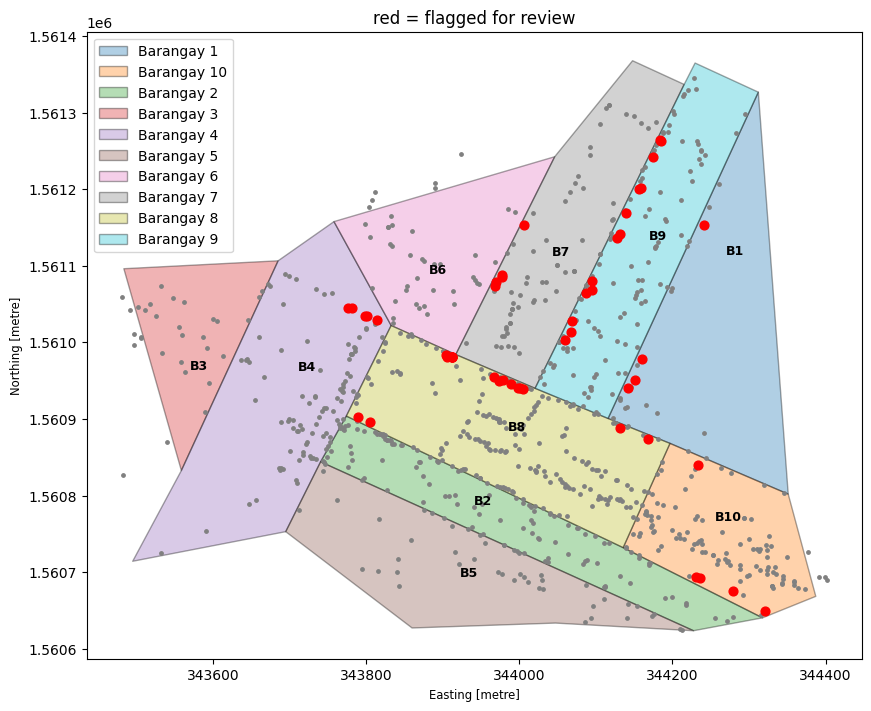

In [1020]:

bad = j[(j["barangay_check"] == "review")]
ax = brgy.plot(column="barangay_poly", figsize=(10, 10), alpha=0.35, edgecolor="black", legend=True)

j.plot(ax=ax, markersize=6, color="gray")
bad.plot(ax=ax, markersize=40, color="red")

for _, r in brgy.iterrows():
    c = r.geometry.representative_point()
    ax.annotate(r["barangay_poly"].replace("Barangay ", "B"), (c.x, c.y), fontsize=9, weight="bold")

ax.set_title("red = flagged for review")
plt.show()

In [1021]:
# barangays with coordinates out of bound
mask = df['barangay'].isna()
print(f"Total: {len(df[ mask ])}")
df[ mask ]


Total: 68


,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check
18,10/03/2026 10:13:15.000 GMT+08:00,19.0,LUC_B10_019,BRGY. MULTI PURPOSE HALL,Government,Barangay Office,San Luis,None,14.11293,121.558487,...,<NA>,<NA>,"Vital, Farrell Richard E.",2026-10-03,<NA>,Yes,1.9,raw_dataset_1,True,outside_polygons
19,10/03/2026 10:16:09.000 GMT+08:00,20.0,LUC_B10_020,Mamet's sari sari store,Retail,Sari Sari Store,San Luis,None,14.1129,121.558577,...,<NA>,<NA>,"Vital, Farrell Richard E.",2026-10-03,<NA>,Yes,2.7,raw_dataset_1,True,outside_polygons
20,10/03/2026 10:16:54.000 GMT+08:00,21.0,LUC_B10_021,Oblenida's sari sari store,Retail,Sari Sari Store,San Luis,None,14.112935,121.558562,...,<NA>,<NA>,"Palegar, Luis Alphonso N.",2026-10-03,<NA>,Yes,1.6,raw_dataset_1,True,outside_polygons
21,10/03/2026 10:21:28.000 GMT+08:00,22.0,LUC_B10_022,MSS Driving School,Other,Other,San Luis,None,14.113223,121.558347,...,<NA>,0966-983-1651,"Vital, Richard Farrell E.",2026-10-03,<NA>,Yes,1.7,raw_dataset_1,True,outside_polygons
107,10/03/2026 15:18:48.000 GMT+08:00,108.0,LUC_B01_006,Flora's Sari-sari Store,Retail,Sari Sari Store,La Purisma Concepcion,None,14.114242,121.557008,...,<NA>,<NA>,"Cadao, Janusz Gabriel S.",2026-10-03,<NA>,Yes,1.7,raw_dataset_1,True,review
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,10/05/2026 09:59:47.000 GMT+08:00,59.0,LUC_B07_059,Philippines Charity Sweepstakes Office Lotto,Personal Services,Lottos,Lucban - Sampaloc Road,None,14.116303,121.555717,...,<NA>,<NA>,"Jabrica, Junell C.",2026-10-05,<NA>,Yes,1.4,raw_dataset_11,True,review
826,10/05/2026 10:00:18.000 GMT+08:00,60.0,LUC_B07_060,Mariel Machineries Inc.,Automotive,Dealership,Lucban - Sampaloc Road,None,14.116263,121.555642,...,<NA>,09626695520,"Inoc, Dyan Michelle N.",2026-10-05,dealership,Yes,1.5,raw_dataset_11,True,review
833,10/05/2026 10:16:28.000 GMT+08:00,67.0,LUC_B07_067,La Barrida's Pizzaria,Food and Dining,Restaurant,Lucban - Sampaloc Road,None,14.115937,121.555475,...,<NA>,<NA>,"Inoc, Dyan Michelle N.",2026-10-05,<NA>,Yes,1.4,raw_dataset_11,True,review
834,10/05/2026 10:16:52.000 GMT+08:00,68.0,LUC_B07_068,Fleur De Ray,Personal Services,Flower Shop,Lucban - Sampaloc Road,None,14.115808,121.555462,...,<NA>,<NA>,"Inoc, Dyan Michelle N.",2026-10-05,boutiwue,Yes,1.5,raw_dataset_11,True,review


##### Create `brgy_from_id` column
Find rows with missing `barangay` value after automated processing, then find the barangay name according to the `feature_id\`

In [1022]:
# Extract the barangay number from the feature_id column
# Feature IDs contain something like 'LUC_B10_019' or 'LUC_B07_087'
# We extract the number after 'B' or 'B0' to format it as 'Barangay X'

# Normalize feature_id to be safe
normalized_id = df['feature_id'].astype(str).str.upper().str.replace('-', '_', regex=False).str.replace('O', '0', regex=False)

# Extract the numeric part following 'B' or 'B0'
brgy_num = normalized_id.str.extract(r'_B0*(\d+)')

if not brgy_num.empty:
    brgy_from_id = "Barangay " + brgy_num[0].astype(str)
    # Fill missing values in 'barangay' column with the extracted values
    df['barangay'] = df['barangay'].fillna(brgy_from_id)

df['barangay'] = df['barangay'].astype('string')
# Verify if we still have missing barangay values
print("Missing barangay counts after filling from feature_id:", df['barangay'].isna().sum())
print(df['barangay'].value_counts(dropna=False))

Missing barangay counts after filling from feature_id: 0
barangay
Barangay 8     166
Barangay 9     126
Barangay 2     116
Barangay 4     105
Barangay 10    102
Barangay 7      91
Barangay 6      68
Barangay 5      37
Barangay 3      30
Barangay 1      17
Name: count, dtype: Int64


In [1023]:
same_id = df["feature_id"] == df_raw["feature_id"]
has_brgy = ~df['barangay'].isna()

df_raw[has_brgy & same_id]['name']

,name
0,"mommy's tacos, burgers and pizzas"
1,bnb laundry
2,Star commecial
3,ICE ICE BABY
4,Zendong
...,...
853,Marnette Laundry Shop
854,SJ TENZEL Hardware & Construction Supply
855,Freyaj & Marga
856,Rose's Arts & Crafts


## Category/Status/Subcategory Fixing


In [1024]:
category_fixes = {
    'Professional Sevices': 'Professional Services'
}

df['category'] = df['category'].replace(category_fixes)
df['category']

,category
0,Food and Dining
1,Personal Services
2,Retail
3,Other
4,Food and Dining
...,...
853,Personal Services
854,Retail
855,Retail
856,Personal Services


In [1025]:
status_fixes = {
    'open': 'Open',
    'OPEN': 'Open',
    'Oepn': 'Open',
    'close': 'Closed',
    'Close': 'Closed',
    'CLOSED': 'Closed',
    'closed': 'Closed',
    'closel': 'Closed'
}

df['operating_status'] = df['operating_status'].replace(status_fixes)
df['operating_status']

,operating_status
0,Open
1,Open
2,Open
3,Open
4,Open
...,...
853,Closed
854,Open
855,Open
856,Closed


In [1026]:
sorted(df['subcategory'].dropna().unique())

['ATM',
 'Animal Care',
 'Arts & Crafts',
 'Bakery',
 'Bank',
 'Bar',
 'Barangay Office',
 'Barbershop',
 'Boarding House',
 'Boutiques',
 'Building Materials Store',
 'CDC',
 'Cafe',
 'Car Rental',
 'Car Wash',
 'Catering Service',
 'Clinic',
 'Clothing',
 'Computer Shop',
 'Convenience Store',
 'Dealership',
 'Dental Clinic',
 'Dentist',
 'Eatery',
 'Electronics',
 'Electronics Repair Shop',
 'Engineering Services',
 'Entrepreneurship',
 'Event Hall',
 'Event Services',
 'Fashion Design',
 'Fast Food',
 'Flower Shop',
 'Food Products',
 'Funeral Service',
 'Gas Station',
 'Grocery',
 'Grocery Store',
 'Hardware Store',
 'Home Appliance Store',
 'Hotel',
 'Inn',
 'Laundry',
 'Laundry Shop',
 'Lending Company',
 'Lodge',
 'Lottos',
 'Massage',
 'Microfinance Institution',
 'Municipal Office',
 'Notary Public',
 'Office',
 'Optometrist',
 'Other',
 'Parts Shop',
 'Pawnshop',
 'Pet Shop',
 'Pharmacy',
 'Photography',
 'Place of Worship',
 'Printing Shop',
 'Remittance Center',
 'Repair S

In [1027]:
subcategory_fixes = {
    'Sari Sari Store': 'Sari-Sari Store',
    'Sari-sari Store': 'Sari-Sari Store',
    'Grocery Store': 'Grocery',
    'Laundry Shop': 'Laundry',
    'Pharmacy Store': 'Pharmacy',
    'Bakeshop': 'Bakery',
    'Convenience Store ': 'Convenience Store',
    'Restaurant ': 'Restaurant',
    'Beauty Salon': 'Salon',
    'Boardinghouse': 'Boarding House',
    'Boarding house': 'Boarding House',
    'Computer shop': 'Computer Shop',
    'Hardware Store': 'Hardware',
    'Auto Repair Shop': 'Auto Repair',
    'Medical Clinic': 'Clinic',
    'Dental Clinic': 'Dentist'
}

df['subcategory'] = df['subcategory'].replace(subcategory_fixes)

In [1028]:
df['subcategory'].value_counts()

,count
subcategory,
Sari-Sari Store,149
Other,134
Eatery,61
Restaurant,45
Grocery,42
...,...
Optometrist,1
Lottos,1
Home Appliance Store,1


In [1029]:
#Missing parameters on street
df[df["street"].isna()]

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check
14,10/03/2026 10:06:31.000 GMT+08:00,15.0,LUC_B10_015,Joey's Barber Shop,Personal Services,Barbershop,<NA>,Barangay 10,14.11289,121.558177,...,<NA>,<NA>,"Broqueza, Mikyla C.",2026-10-03,<NA>,Yes,1.9,raw_dataset_1,True,ok
221,10/03/2026 15:36:05.000 GMT+08:00,78,LUC_B09_078,Levy Store,Retail,Sari-Sari Store,<NA>,Barangay 9,14.116874,121.556517,...,<NA>,<NA>,"Javin, Mark Justine P.",2026-10-03,<NA>,Yes,3.79,raw_dataset_3,True,ok
294,10/01/2026 16:36:11.000 GMT+08:00,26,LUC_B08_055,Cristina's Palamigan,Retail,Sari-Sari Store,<NA>,Barangay 8,14.114753,121.55423,...,<NA>,<NA>,"Alfaro, Justin Alexandre B.",2026-10-01,<NA>,Yes,2.5,raw_dataset_4,True,ok
336,10/03/2026 09:10:40.000 GMT+08:00,4,LUC_B05_003,Pedron Dental Clinic,Health,Dentist,<NA>,Barangay 5,14.112435,121.555725,...,Monday-Saturday: 9:00 AM - 6 PM,FB: PedronDentalClinic,"Dela Cruz, Shane Theresse A.",2026-10-03,<NA>,Yes,10.7,raw_dataset_5,True,ok
348,10/03/2026 10:54:03.000 GMT+08:00,19,LUC_B05_013,Bigasan ng Bayan Wholesale & Retail,Retail,Grocery,<NA>,Barangay 5,14.113702,121.553697,...,<NA>,09664002301,"Dela Cruz, Shane Theresse A.",2026-10-03,<NA>,Yes,10.7,raw_dataset_5,True,ok
362,10/03/2026 11:58:17.000 GMT+08:00,36,LUC_B05_027,Pablo's Store,Retail,Sari-Sari Store,<NA>,Barangay 5,14.112965,121.554597,...,<NA>,<NA>,"Dela Cruz, Shane Theresse A.",2026-03-20,<NA>,Yes,11.7,raw_dataset_5,True,ok
420,10/01/2026 15:01:22.000 GMT+08:00,50,LUC_B08_010,Atinto Travel and Tours,Tourism,Tourism Service,<NA>,Barangay 8,14.11365,121.55533,...,<NA>,<NA>,"Erinco, Raphael Joshua V.",2026-10-01,<NA>,Yes,9.935,raw_dataset_6,True,ok
421,10/01/2026 15:02:51.000 GMT+08:00,51,LUC_B08_021,Radyo Natin,Other,Other,<NA>,Barangay 8,14.11363,121.555274,...,<NA>,<NA>,"Apostol, Janelle Mae A.",2026-10-01,Radio station,Yes,10.224,raw_dataset_6,True,boundary
600,09/28/2026 21:21:34.000 GMT+08:00,2,LUC_B02_020,Shower Of Blessing,Retail,Grocery,<NA>,Barangay 2,14.113766,121.554399,...,<NA>,(042) 540-6181,"Arellano, Arvin L.",2026-09-28,<NA>,Yes,3.79,raw_dataset_8,True,ok


*italicized text*## Missing Values for the not-required fields

In [1030]:
### Filling missing values: (Remarks, contactinfo, location description) / # Junell

# Missing value for remarks
df[df["remarks"].isna()]

# fill missing values with "Not provided"
df["remarks"] = df["remarks"].fillna("Not Provided")

# check if the data is filled
df["remarks"].value_counts()

,count
remarks,
Not Provided,766
Church,2
dealership,2
Closed on weekends,2
Water Refilling Station,2
...,...
boutiwue,1
Shoe Store,1
Photography,1


In [1031]:
#Checking for missing values on contact info
df[df["contact_info"].isna()]

# fill missing values with "Not provided"
df["contact_info"] = df["contact_info"].fillna("Not Provided")

# check if the data is filled
df["contact_info"].value_counts()

,count
contact_info,
Not Provided,702
09157217881,2
09683610654,2
9985675637,2
9196312215,2
...,...
09073447508,1
09635134888,1
09994468475,1


In [1032]:
# Location Description
df[df["location_description"].isna()]

# fill missing values with "Not provided"
df["location_description"] = df["location_description"].fillna("Not Provided")

df['location_description'].value_counts()

,count
location_description,
Not Provided,757
faced with a empty lot,2
School and Office Supplies,2
2nd Floor,2
tapat ng ongville,2
...,...
"corner of the street. connected to RRN Interactive Clinic, Skin Health Clinic, and Parinas Medical Clinic",1
"Corner of the street. Connected with RMT's Clinical Laboratory, RRN Integrative Health Clinic, and Parinas Health Clinic",1
"Corner of the street. Connected to RRN Integrative Health Clinic, RMT's Clinical Laboratory, and The Skin Health Clinic",1


## Fixing Feature ID

In [1033]:
# Obtain barangay number from barangay field and pad to 2 digits
brgy_num_extracted = df['barangay'].astype(str).str.extract(r'(\d+)')[0].fillna('XX').str.zfill(2)

# Obtain ID number and clean
id_num_clean = df['ID'].astype(str).str.split('.').str[0].str.zfill(3)

# 3. Create a new feature id in the form of LUC_B{barangay_number}_{ID}
new_ids = 'LUC_B' + brgy_num_extracted + '_' + id_num_clean

# 4. Use it as the new feature_id
df['feature_id'] = new_ids.astype('string')

# Display the top rows to verify
display(df[['barangay', 'ID', 'feature_id']].head(5))
len(df['feature_id'].unique())



,barangay,ID,feature_id
0,Barangay 10,1.0,LUC_B10_001
1,Barangay 10,2.0,LUC_B10_002
2,Barangay 10,3.0,LUC_B10_003
3,Barangay 10,4.0,LUC_B10_004
4,Barangay 10,5.0,LUC_B10_005


768

In [1034]:
df = df.sort_values(by=['barangay', 'date_collected']).reset_index(drop=True)

# group by barangay and assign a cumulative count starting at 1
df['new_seq_id'] = df.groupby('barangay').cumcount() + 1

# format the sequence ID to 3 digits (e.g., 001, 002)
seq_id_padded = df['new_seq_id'].astype(str).str.zfill(3)

# Extract barangay number
brgy_num_extracted = df['barangay'].astype(str).str.extract(r'(\d+)')[0].fillna('XX').str.zfill(2)

# Combine to make a unique feature_id
df['feature_id'] = 'LUC_B' + brgy_num_extracted + '_' + seq_id_padded

# Drop the helper sequence column
df = df.drop(columns=['new_seq_id'])

# Verify uniqueness
print("Total rows:", len(df))
print("Unique feature IDs:", df['feature_id'].nunique())
print("Duplicated feature IDs:", df['feature_id'].duplicated().sum())
display(df[['barangay', 'feature_id']].head())

Total rows: 858
Unique feature IDs: 858
Duplicated feature IDs: 0


,barangay,feature_id
0,Barangay 1,LUC_B01_001
1,Barangay 1,LUC_B01_002
2,Barangay 1,LUC_B01_003
3,Barangay 1,LUC_B01_004
4,Barangay 1,LUC_B01_005


In [1035]:
df['feature_id'].value_counts()

,count
feature_id,
LUC_B09_126,1
LUC_B01_001,1
LUC_B01_002,1
LUC_B01_003,1
LUC_B01_004,1
...,...
LUC_B01_015,1
LUC_B01_014,1
LUC_B01_013,1


## Filling the non-required missing values

In [1036]:
### Filling missing values: (Remarks, contactinfo, location description) / # Junell

# Missing value for remarks
df[df["remarks"].isna()]

# fill missing values with "Not provided"
df["remarks"] = df["remarks"].fillna("Not Provided")

# check if the data is filled
df["remarks"].value_counts()

,count
remarks,
Not Provided,766
Church,2
Water Refilling Station,2
dealership,2
Closed on weekends,2
...,...
Beauty clinic,1
Bridal bouquet,1
Cleaning services,1


In [1037]:
#Checking for missing values on contact info
df[df["contact_info"].isna()]

# fill missing values with "Not provided"
df["contact_info"] = df["contact_info"].fillna("Not Provided")

# check if the data is filled
df["contact_info"].value_counts()

,count
contact_info,
Not Provided,702
09157217881,2
09683610654,2
9985675637,2
9196312215,2
...,...
9608518275,1
9208344071,1
9127909256,1


In [1038]:
# Location Description
df[df["location_description"].isna()]

# fill missing values with "Not provided"
df["location_description"] = df["location_description"].fillna("Not Provided")

# check if the data is filled
df["location_description"].value_counts()

,count
location_description,
Not Provided,757
faced with a empty lot,2
School and Office Supplies,2
2nd Floor,2
tapat ng ongville,2
...,...
Second floor,1
first floor,1
second floor,1


In [1039]:
# opening_hours
df[df["opening_hours"].isna()]

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check
0,10/03/2026 15:06:53.000 GMT+08:00,103.0,LUC_B01_001,Mr. Yap Fresh Buko,Other,Other,Quezon Avenue,Barangay 1,14.113918,121.558059,...,<NA>,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.6,raw_dataset_1,True,boundary
1,10/03/2026 15:09:48.000 GMT+08:00,104.0,LUC_B01_002,Osolle Electrical Supply,Retail,Electronics,La Purisma Concepcion,Barangay 1,14.11401,121.557813,...,<NA>,09605149058,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.6,raw_dataset_1,True,boundary
2,10/03/2026 15:11:35.000 GMT+08:00,105.0,LUC_B01_003,Rkov Motorcle Parts,Automotive,Parts Shop,La Purisma Concepcion,Barangay 1,14.11416,121.55741,...,<NA>,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.7,raw_dataset_1,True,boundary
3,10/03/2026 15:12:59.000 GMT+08:00,106.0,LUC_B01_004,Yssa's Sari-sari Store,Retail,Sari-Sari Store,La Purisma Concepcion,Barangay 1,14.114218,121.557288,...,<NA>,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.6,raw_dataset_1,True,boundary
4,10/03/2026 15:16:56.000 GMT+08:00,107.0,LUC_B01_005,Purr J,Retail,Other,La Purisma Concepcion,Barangay 1,14.114335,121.557112,...,<NA>,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.5,raw_dataset_1,True,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,10/03/2026 16:47:39.000 GMT+08:00,122,LUC_B09_122,Marinduqueños,Food and Dining,Fast Food,Lucban-Sampaloc Road,Barangay 9,14.118677,121.556859,...,<NA>,Not Provided,"Escobal, Gwyneth A.",2026-10-03,Not Provided,Yes,3.79,raw_dataset_3,True,ok
854,10/03/2026 16:49:54.000 GMT+08:00,123,LUC_B09_123,Malen store,Retail,Sari-Sari Store,Gil Rada,Barangay 9,14.118688,121.556962,...,<NA>,Not Provided,"Salumbides, Emanuel A.",2026-10-03,Not Provided,Yes,9.935,raw_dataset_3,True,ok
855,10/03/2026 16:53:14.000 GMT+08:00,124,LUC_B09_124,Lena's Store,Retail,Sari-Sari Store,Gil Rada,Barangay 9,14.118387,121.557556,...,<NA>,Not Provided,"Reginal, Reynel M.",2026-10-03,Not Provided,Yes,9.935,raw_dataset_3,True,ok
856,10/03/2026 16:55:39.000 GMT+08:00,125,LUC_B09_125,Rosalyn store,Retail,Sari-Sari Store,Don V. Cadelina,Barangay 9,14.118164,121.557447,...,<NA>,Not Provided,"Javin, Mark Justine P.",2026-10-03,Not Provided,Yes,3.79,raw_dataset_3,True,ok


In [1040]:
# opening_hours
df[df["opening_hours"].isna()]

#filled missing values for operating hours
df["opening_hours"] = df["opening_hours"].fillna("Not Provided")

# check if the data is filled
df["location_description"].value_counts()

,count
location_description,
Not Provided,757
faced with a empty lot,2
School and Office Supplies,2
2nd Floor,2
tapat ng ongville,2
...,...
Second floor,1
first floor,1
second floor,1


## Manual Corrections and Value Fixing

In [1041]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing = missing.sort_values(
    'missing_percent',
    ascending=False
)

missing

,missing_count,missing_percent
name,23,2.680653
street,9,1.048951
operating_status,5,0.582751
feature_id,0,0.000000
ID,0,0.000000
Time,0,0.000000
subcategory,0,0.000000
category,0,0.000000
Latitude,0,0.000000
barangay,0,0.000000


In [1042]:
df['date_collected'] = pd.to_datetime(
    df['date_collected'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [1043]:
df['date_collected'].min()
df['date_collected'].max()

future_dates = df[
    df['date_collected'] > pd.Timestamp('2026-12-31')
]

future_dates

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check
406,10/03/2026 11:18:51.000 GMT+08:00,25,LUC_B05_037,Apo ni Luming pansitan,Food and Dining,Eatery,Marcus Tigla St,Barangay 5,14.113587,121.553157,...,Not Provided,09685260922,"Liwanag, Micaela A.",2206-10-03,Not Provided,Yes,12.4,raw_dataset_5,True,ok


In [1044]:
df[df['date_collected'].isna()]

,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check


### Counting Missing Establishment Names in Data

In [1045]:

df['collector'] = df['collector'].apply(format_collector)

# Then slice the missing rows (so they include collectors_clean)
missing_name_rows = df[df['name'].isna()]

print(f"Number of Missing Names: {len(missing_name_rows)}")
print(missing_name_rows.to_string())

missing_by_barangay = missing_name_rows.groupby('barangay').size()
print("\n=== Missing Establishment Names per Barangay ===")
print(missing_by_barangay.to_string())

collector_missing_freq = missing_name_rows.groupby('collector').size()
print("\n=== Collector Frequency for Missing Entries ===")
print(collector_missing_freq.to_string())

Number of Missing Names: 23
                                  Time   ID   feature_id  name           category      subcategory          street    barangay   Latitude   Longitude location_description operating_status    opening_hours  contact_info                  collector date_collected                                   remarks verified  Horizontal Accuracy         source  correct_format barangay_check
119  09/28/2026 20:05:30.000 GMT+08:00    1  LUC_B02_001  <NA>      Accommodation   Boarding House      A. Racelis  Barangay 2  14.112478  121.557781         Not Provided             <NA>     Not Provided  Not Provided             Palma, Mark M.     2026-09-28                              Not Provided      Yes                 3.79  raw_dataset_7            True       boundary
266  09/29/2026 18:11:12.000 GMT+08:00    2  LUC_B04_002  <NA>             Retail            Other      Conception  Barangay 4  14.116294  121.552381         Not Provided             Open  5:30am - 8:00pm    939321

In [1046]:
unfiltered_df = df[df['collector'].str.contains('susin', case=False) ]

print(unfiltered_df.to_string())

df['collector'] = df['collector'].str.replace('Susin', 'Susim')

# Validated
filtered_df = df[df['collector'].str.contains('susin', case=False) ]

print(filtered_df.to_string())

                                  Time  ID   feature_id                        name         category      subcategory               street    barangay   Latitude   Longitude                   location_description operating_status     opening_hours   contact_info               collector date_collected         remarks verified  Horizontal Accuracy         source  correct_format barangay_check
372  10/03/2026 09:04:16.000 GMT+08:00   3  LUC_B05_003  Brgy. 5 Multi-Purpose Hall       Government  Barangay Office       Balintawak St.  Barangay 5  14.112387  121.555653              Dulo ng balintawak street             Open   8:00am - 5:00pm   Not Provided  Susin, Mark Gabriel E.     2026-10-03    Not Provided      Yes                 12.3  raw_dataset_5            True             ok
383  10/03/2026 10:50:37.000 GMT+08:00  17  LUC_B05_014        Jia's Consumer Goods           Retail  Sari-Sari Store    Fidel Rada Street  Barangay 5  14.113663  121.553802                infront gogo car rental

###Street Name Formatting

In [1047]:
# Map Street Names With Their Incorrect Names
street_map = {
    # A. Bonifacio
    'Bonifacio': 'A. Bonifacio',
    'Bonifacio Street': 'A. Bonifacio',
    'A. Bonifacio Street': 'A. Bonifacio',

    # A. Mabini
    'A. Mabini Street': 'A. Mabini',
    'A. Mabini St.': 'A. Mabini',
    'Apolinario Mabini': 'A. Mabini',
    'Mabini': 'A. Mabini',

    # A. Racelis Avenue
    'A. Racelis': 'A. Racelis Avenue',
    'Racelis': 'A. Racelis Avenue',
    'Racelis Street': 'A. Racelis Avenue',
    'Armando Racelis Avenue': 'A. Racelis Avenue',

    # Balintawak Street
    'Balintawak': 'Balintawak Street',
    'Balintawak St.': 'Balintawak Street',

    # Cadavez Street
    'Cadavez St.': 'Cadavez Street',
    '129 Cadavez St.': 'Cadavez Street',

    # D. Aguilar
    'D. Agular': 'D. Aguilar',

    # Don V. Cadelina
    'Don V . Cadelina': 'Don V. Cadelina',
    'Don V. Cadeliña Streeg': 'Don V. Cadelina',

    # E. Zurbano
    'E. Zurbano Street': 'E. Zurbano',

    # Emilio Jacinto Street
    'Emilio Jacinto': 'Emilio Jacinto Street',
    'Emilio Jacinto St.': 'Emilio Jacinto Street',

    # Fidel Rada Street
    'Fidel Rada': 'Fidel Rada Street',
    'Fidel Rada St': 'Fidel Rada Street',
    'Fidel Rada St.': 'Fidel Rada Street',
    'Fidel Rada Stm': 'Fidel Rada Street',

    # G. Cadeliña
    'G.Cadeliña': 'G. Cadeliña',

    # G. Del Pilar
    'G Del Pilar': 'G. Del Pilar',
    'G. Del Pilar Street': 'G. Del Pilar',

    # Gen. Lukban
    'General Lukban Street': 'Gen. Lukban',
    'General Lukban': 'Gen. Lukban',
    'General Lukban St.': 'Gen. Lukban',
    'Gen. Lucban': 'Gen. Lukban',
    'Gen Lukban': 'Gen. Lukban',

    # Gomburza Street
    'Gomburza': 'Gomburza Street',
    'Gomburza St.': 'Gomburza Street',

    # Hobart Dator Street
    'Hobart Dator St.': 'Hobart Dator Street',
    '15 Hobart Dator St.': 'Hobart Dator Street',
    'H. Dator': 'Hobart Dator Street',

    # Jose Eleazar
    'Sn. Jose': 'Jose Eleazar',

    # La Purisima Concepcion
    'La Purisma Concepcion': 'La Purisima Concepcion',
    'La Purisima Conception': 'La Purisima Concepcion',
    'Conception': 'La Purisima Concepcion',
    'Conception Street': 'La Purisima Concepcion',

    # Lucban-Sampaloc Road
    'Lucban - Sampaloc Road': 'Lucban-Sampaloc Road',
    'Lucban Sampaloc Road': 'Lucban-Sampaloc Road',

    # Marcos Tigla Street
    'Marcos Tigla': 'Marcos Tigla Street',
    'Marcos Tigla St.': 'Marcos Tigla Street',
    'Marcus Tigla St': 'Marcos Tigla Street',

    # Regidor
    'A. Regidor': 'Regidor',

    # Rizal Avenue
    'Rizal Ave.': 'Rizal Avenue',

    # San Luis
    'San Luis Cor. G. Cadeliña': 'San Luis',

    # A. Maderal Street
    'A. Maderal St.': 'A. Maderal Street'
}

In [1048]:
df['street'] = df['street'].apply(clean_street_names)

print(df['street'].value_counts())

street
Quezon Avenue             112
A. Racelis Avenue          94
La Purisima Concepcion     69
Lucban-Sampaloc Road       58
San Luis                   56
A. Bonifacio               51
A. Mabini                  38
Gen. Lukban                38
Katipunan                  37
Fidel Rada Street          32
Regidor                    31
Gomburza Street            31
Don V. Cadelina            19
Lopez Jaena                16
Balintawak Street          15
Emilio Jacinto Street      14
Marcos Tigla Street        14
Claro Cabungcal            13
Rizal Avenue               13
Placencia Street           13
G. Cadeliña                12
A. Dela Cruz               10
Plaridel                   10
Hobart Dator Street         9
D. Aguilar                  8
Jose Eleazar                7
G. Del Pilar                6
Cadavez Street              6
C. Arellano                 6
R. Villasenor               3
B. Tolentino                2
A. Maderal Street           2
Gil Rada                    2
Sua

In [1049]:
bonifacio_st = df[df['street'] == 'Racelis']

print(bonifacio_st.to_string())


Empty DataFrame
Columns: [Time, ID, feature_id, name, category, subcategory, street, barangay, Latitude, Longitude, location_description, operating_status, opening_hours, contact_info, collector, date_collected, remarks, verified, Horizontal Accuracy, source, correct_format, barangay_check]
Index: []


### Fixing Individual Collector Names

In [1050]:
# 1) Generic tidy-up: trim and collapse repeated spaces
df["collector"] = df["collector"].str.strip().str.replace(r"\s+", " ", regex=True)

# 2) Map every variant to one canonical "Surname, Given Names M." spelling
name_map = {
    "A., Escobal Gwyneth":        "Escobal, Gwyneth A.",
    "M, Reginal Reynel":          "Reginal, Reynel M.",
    "Escobal, Gwyneth":           "Escobal, Gwyneth A.",
    "Escobal, Gwyneth A":         "Escobal, Gwyneth A.",
    "Alfaro, Justin Alexadre B":  "Alfaro, Justin Alexandre B.",
    "Alfaro, Justin Alexandre B": "Alfaro, Justin Alexandre B.",
    "Salumbides, Emanuel":        "Salumbides, Emanuel A.",
    "Salumbides, Emanuel A":      "Salumbides, Emanuel A.",
    "Quebrado, Lance":            "Quebrado, Lance Wayne Y.",
    "Quebrado, Lance Wayne":      "Quebrado, Lance Wayne Y.",
    "Terrenal, Tiara":            "Terrenal, Tiara Joy V.",
    "Gonzales, Louis":            "Gonzales, John Louis Q.",
    "Gonzalez, Louis":            "Gonzales, John Louis Q.",
    "Macaraig, Mark Rheniel P":   "Macaraig, Mark Rheniel P.",
    "Macaraig, Mark Rheniel M.":  "Macaraig, Mark Rheniel P.",
    "Hutamares, Chezka":          "Hutamares, Franchezka M.",
    "Hutamares, Franchezka S.":   "Hutamares, Franchezka M.",
    "Vital, Farrell Richard E.":  "Vital, Richard Farrell E.",
}

df["collector"] = df["collector"].replace(name_map)

### Fixing Operating Hours

**Required Format:** `12:34 AM - 12:34 PM`

#### Display Rows TBF
> NOTE: imomove ang function na ito sa taas is ever! 😊

In [1051]:

def display_mismatched_hours(display=False):
  """
  it returns the rows with inapropriately formatted opening hours
  """
  # Regular expression pattern to strictly match 'HH:MM AM - HH:MM PM'
  strict_pattern = r'^(0[1-9]|1[0-2]):[0-5][0-9] (AM|PM) - (0[1-9]|1[0-2]):[0-5][0-9] (AM|PM)$'

  # Identify non-matching rows
  non_conforming = df[
      ~df['opening_hours'].astype(str).str.match(strict_pattern, na=False)
  ]

  print(f"Total non-conforming rows: {len(non_conforming)}")
  if display:
    return non_conforming

In [1052]:
display_mismatched_hours()

Total non-conforming rows: 858


#### Fix Simple Format Issues

* Missing space
* Missing dash
* AM/PM capitalization

In [1053]:
def clean_opening_hours(val):
    if pd.isna(val) or val == "Not Provided" or val == "24/7":
        return val

    # strip whitespace
    s = str(val).strip()

    # capitalize all AM, PM, NN (Noon)
    s = s.upper()

    # replace 'TO' or 'UNTIL' with a dash
    s = re.sub(r'\s+(TO|UNTIL)\s+', ' - ', s, flags=re.IGNORECASE)

    # add spaces around dash if they are missing
    if '-' in s:
        parts = s.split('-')
        s = ' - '.join([p.strip() for p in parts])

    # Match and clean times that miss a colon or spacing before AM/PM (e.g., '9AM' -> '09:00 AM')
    # This handles both sides of the dash
    def format_time_segment(match):
        hour = match.group(1)
        minute = match.group(3) if match.group(3) else '00'
        period = match.group(4)

        # Handle '12:00 NN' to PM or noon if applicable, but standard strictly uses AM/PM
        if period == 'NN' or period == 'NOON':
            period = 'PM'

        # Ensure hour has leading zero if single digit
        if len(hour) == 1:
            hour = '0' + hour

        return f"{hour}:{minute} {period}"

    # Regex for a time unit: (H or HH)(:(MM))? (space)?
    time_regex = r'\b(0?[1-9]|1[0-2])(:([0-5][0-9]))?\s*(AM|PM|NN|NOON)\b'
    s = re.sub(time_regex, format_time_segment, s)

    return s

# Apply the cleaning function to the dataset
df['opening_hours'] = df['opening_hours'].apply(clean_opening_hours)

# Quick preview of unique values remaining
print("Unique opening hours values after cleanup:")
display(df['opening_hours'].value_counts())

Unique opening hours values after cleanup:


,count
opening_hours,
Not Provided,725
08:00 AM - 05:00 PM,11
07:00 AM - 09:00 PM,7
24 - JUL,6
07:00 AM - 07:00 PM,6
...,...
10:00 AM - 06:00 PM,1
09:00 AM,1
09:00 AM - 05:30 PM,1


In [1054]:
mismatches = display_mismatched_hours(display=True)
mismatches.head(3)

Total non-conforming rows: 743


,Time,ID,feature_id,name,category,subcategory,street,barangay,Latitude,Longitude,...,opening_hours,contact_info,collector,date_collected,remarks,verified,Horizontal Accuracy,source,correct_format,barangay_check
0,10/03/2026 15:06:53.000 GMT+08:00,103.0,LUC_B01_001,Mr. Yap Fresh Buko,Other,Other,Quezon Avenue,Barangay 1,14.113918,121.558059,...,Not Provided,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.6,raw_dataset_1,True,boundary
1,10/03/2026 15:09:48.000 GMT+08:00,104.0,LUC_B01_002,Osolle Electrical Supply,Retail,Electronics,La Purisima Concepcion,Barangay 1,14.11401,121.557813,...,Not Provided,09605149058,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.6,raw_dataset_1,True,boundary
2,10/03/2026 15:11:35.000 GMT+08:00,105.0,LUC_B01_003,Rkov Motorcle Parts,Automotive,Parts Shop,La Purisima Concepcion,Barangay 1,14.11416,121.55741,...,Not Provided,Not Provided,"Cadao, Janusz Gabriel S.",2026-10-03,Not Provided,Yes,1.7,raw_dataset_1,True,boundary


#### Fix Remaining Rows

This section fixes the rows indicating **24/7 opening hours**

##### The rows affected by this section includes rows with values:
* 24/7
* 24 - July (*Which occured from excel corruption*)
* 24HRS
* 24HOURS

The rest of rows that fails to match these patters will fall into `Not Provided`

In [1055]:
# Define the regex pattern for 24-hour indicators
# This matches '24/7', '24HRS', '24 HOURS', and Excel-corrupted '24 - JUL'
pattern_24h = r'(?i)\b(24\s*/\s*7|24\s*-\s*JUL|24\s*HRS|24\s*HOURS)\b'

# Identify non-matching rows using the predefined strict pattern
strict_pattern = r'^(0[1-9]|1[0-2]):[0-5][0-9] (AM|PM) - (0[1-9]|1[0-2]):[0-5][0-9] (AM|PM)$'
non_conforming_mask = ~df['opening_hours'].astype(str).str.match(strict_pattern, na=False)

def resolve_remaining_hours(val):
    # keep rows with "Not Provided" value
    if val == "Not Provided":
        return val

    # If it indicates 24 hours, map to '24/7'
    if re.search(pattern_24h, str(val)):
        return '24/7'

    # Fallback all other remaining non-conforming entries to 'Not Provided'
    return 'Not Provided'

# Apply the transformation to non-conforming rows only
df.loc[non_conforming_mask, 'opening_hours'] = df.loc[non_conforming_mask, 'opening_hours'].apply(resolve_remaining_hours)

df["opening_hours"] = df["opening_hours"].astype('string')

### Fix Remarks/Subcategory

#### Display Unique Remarks

##### All remarks as list

In [1056]:
remarks_list = [
    "Not Provided",
    "Water Refilling Station",
    "Church",
    "Closed on weekends",
    "dealership",
    "Closed on Saturdays",
    "Long standing grocery for sari sari store",
    "Water Refilling station",
    "Vape Shop",
    "Spa Salon",
    "Animal Feeds",
    "Messenger: Lailani Divina Abuel Arellano",
    "Shipping Hub",
    "Funeral Services",
    "Footwears",
    "Meat Products",
    "8 students per class",
    "funeral home",
    "water refilling station",
    "Near Multi purpose hall",
    "Consumer Goods",
    "digital photography & video coverage",
    "Nail Salon",
    "Water station",
    "Dermatology Clinic",
    "Day off on Mondays",
    "Hardware Repair",
    "Flower Shop",
    "Car Wash",
    "Electrical Engineering Services",
    "Tricycle Station",
    "Bar",
    "Office related to OFWs",
    "Closed on Sundays",
    "Lottery",
    "Event Place",
    "Tile Shop/Hardware",
    "Building mats store",
    "loaning company",
    "Rice Store",
    "Veterinary",
    "Pet Shop",
    "Event Item Renting",
    "Electronic Components Store",
    "Boutiques",
    "hardware",
    "Music Renting",
    "catering Service",
    "Dentist",
    "Hardware Store",
    "Title Transfer and Real Estate",
    "Eye Clinic",
    "Home Appliances",
    "Electrical Supplies",
    "boutiwue",
    "Shoe Store",
    "Photography",
    "Notary Public",
    "Dealership",
    "Subcategory is Others because madaming tinda",
    "Convenience Store",
    "law office notary",
    "Fruit store",
    "Raw chicken shop",
    "Cooked Chicken shop",
    "3rd Floor - Transient Room",
    "Lutong Chicken Shop",
    "No Label",
    "Residential Office at tindahan ng lambanog, open daw sila",
    "Bawal itanong ang name, wala raw yung owner, pero kind yung seller",
    "general merchandise",
    "School",
    "lamayan/burulan malapit sa simbahan",
    "court",
    "Radio station",
    "Event Hall",
    "Ayaw sabihin name magagalitan daw si ate",
    "Ukayan tapat watson",
    "Ai sizzler",
    "sarado na",
    "Beauty products",
    "Liquor",
    "Chapel",
    "Child care and development center",
    "Meat shop",
    "Beauty clinic",
    "Bridal bouquet",
    "Cleaning services",
    "Online Store",
    "Gasul",
]

##### Subcategory as Dict

In [1057]:
additional_subcategories = {
    "Food and Dining": [
        "Meat Products",
        "Rice Store",
        "Fruit Store",
        "Raw Chicken Shop",
        "Cooked Chicken Shop",
        "Lutong Chicken Shop",
        "Catering Service",
        "Ai Sizzler",
        "Bar",
        "Liquor",
        "Animal Feeds",
    ],

    "Retail": [
        "Water Refilling Station",
        "Water Station",
        "Vape Shop",
        "Footwear Store",
        "Flower Shop",
        "Tile Shop",
        "Building Materials Store",
        "Pet Shop",
        "Electronic Components Store",
        "Boutique",
        "Music Rental",
        "Home Appliances",
        "Electrical Supplies",
        "Shoe Store",
        "Convenience Store",
        "General Merchandise",
        "Ukay-Ukay",
        "Beauty Products",
        "Gasul Retailer",
        "Lottery Outlet",
        "Online Store",
    ],

    "Accommodation": [
        "Transient Room",
    ],

    "Financial": [
        "Loaning Company",
    ],

    "Health": [
        "Dermatology Clinic",
        "Veterinary Clinic",
        "Eye Clinic",
        "Beauty Clinic",
    ],

    "Personal Services": [
        "Spa Salon",
        "Nail Salon",
        "Car Wash",
        "Funeral Services",
        "Funeral Home",
        "Event Item Rental",
        "Cleaning Services",
        "Bridal Bouquet Services",
    ],

    "Automotive": [
        "Dealership",
        "Hardware Repair",
        "Electrical Supplies and Repair",
    ],

    "Professional Services": [
        "Electrical Engineering Services",
        "Digital Photography and Video Coverage",
        "Photography Services",
        "Notary Public",
        "Law Office",
        "Title Transfer and Real Estate Services",
        "Office for Overseas Filipino Workers",
        "Radio Station",
        "Shipping Hub",
    ],

    "Government": [],

    "Tourism": [
        "Event Place",
        "Event Hall",
    ],

    "Other": [
        "Church",
        "Chapel",
        "School",
        "Child Care and Development Center",
        "Court",
        "Tricycle Station",
    ],
}

total = 0
for key, val in additional_subcategories.items():
    total += len(val)

print('Total Subcategories: ', total)

Total Subcategories:  66


##### Unusable Remarks

In [1058]:
import pandas as pd
import re

# Expand mapping from both standard additional_subcategories and inconsistent remarks formats
remark_to_subcategory = {}

# Build base mapping from defined subcategories
for subcat_group, remarks_list_sub in additional_subcategories.items():
    for remark in remarks_list_sub:
        norm_key = re.sub(r'\s+', ' ', remark.strip().lower())
        remark_to_subcategory[norm_key] = remark

# Add manual mapping variations for mismatched spelling, plurals, and format variants
manual_extra_mappings = {
    "water refilling station": "Water Refilling Station",
    "water refilling station ": "Water Refilling Station",
    "water station": "Water Refilling Station",
    "dealership": "Dealership",
    "funeral home": "Funeral Home",
    "funeral services": "Funeral Services",
    "boutiwue": "Boutique",
    "boutiques": "Boutique",
    "ukayan tapat watson": "Ukay-Ukay",
    "raw chicken shop": "Raw Chicken Shop",
    "cooked chicken shop": "Cooked Chicken Shop",
    "lutong chicken shop": "Cooked Chicken Shop",
    "gasul": "Gasul Retailer",
    "hardware": "Hardware Store",
    "hardware store": "Hardware Store",
    "dentist": "Dentist",
    "spa salon": "Spa Salon",
    "nail salon": "Nail Salon",
    "fruit store": "Fruit Store",
    "rice store": "Rice Store",
    "meat products": "Meat Products",
    "meat shop": "Meat Products",
    "veterinary": "Veterinary Clinic",
    "music renting": "Music Rental",
    "event item renting": "Event Item Rental",
    "footwears": "Footwear Store",
    "building mats store": "Building Materials Store",
    "tile shop/hardware": "Tile Shop",
    "law office notary": "Law Office",
    "loaning company": "Loaning Company",
    "catering service": "Catering Service",
    "ai sizzler": "Ai Sizzler",
    "bridal bouquet": "Bridal Bouquet Services",
    "cleaning services": "Cleaning Services",
    "general merchandise": "General Merchandise",
    "radio station": "Radio Station",
    "shipping hub": "Shipping Hub",
    "child care and development center": "Child Care and Development Center",
    "beauty clinic": "Beauty Clinic",
    "beauty products": "Beauty Products",
    "liquor": "Liquor",
    "bar": "Bar",
    "chapel": "Chapel",
    "church": "Church",
    "school": "School",
    "court": "Court",
    "tricycle station": "Tricycle Station",
    "transient room": "Transient Room",
    "3rd floor - transient room": "Transient Room",
    "dermatology clinic": "Dermatology Clinic",
    "eye clinic": "Eye Clinic",
    "pet shop": "Pet Shop",
    "electronic components store": "Electronic Components Store",
    "home appliances": "Home Appliances",
    "electrical supplies": "Electrical Supplies",
    "shoe store": "Shoe Store",
    "convenience store": "Convenience Store",
    "online store": "Online Store",
    "event place": "Event Place",
    "event hall": "Event Hall"
}

remark_to_subcategory.update(manual_extra_mappings)

def resolve_subcategory_strict(row):
    """
    Resolves the subcategory by checking if the existing one is missing or generic.
    If so, check if the remark can be mapped to a known subcategory.
    If the remark exists but fails to map to any valid subcategory, maps it to 'Not Provided'.
    Also, if a remark is successfully used for the subcategory, we clear the remark.
    """
    sub = row['subcategory']
    rem = row['remarks']

    # Check if existing subcategory is missing or generic
    is_generic_or_null = pd.isna(sub) or str(sub).strip().lower() in ['', 'nan', 'other', 'others', '<na>', 'none']

    if is_generic_or_null:
        if not pd.isna(rem):
            norm_remark = re.sub(r'\s+', ' ', str(rem).strip().lower())

            # if it matches our mapping dictionary, extract the standard name
            if norm_remark in remark_to_subcategory:
                resolved_val = remark_to_subcategory[norm_remark]
                if resolved_val == 'Water Station':
                    resolved_val = 'Water Refilling Station'

                # Return the resolved value and flag that remark was used
                return resolved_val, "Not Provided"

            # If there is a remark but it does not map to any valid category, return 'Not Provided'
            if norm_remark not in ['', 'not provided']:
                return 'Not Provided', rem

        return 'Not Provided', rem

    # Standardize already-existing subcategories too
    if str(sub).strip() == 'Water Station':
        return 'Water Refilling Station', rem

    return sub, rem

# Apply the strict resolution logic and update both subcategory and remarks columns
results = df.apply(resolve_subcategory_strict, axis=1)
df['subcategory'] = results.apply(lambda x: x[0]).astype('string')
df['remarks'] = results.apply(lambda x: x[1]).astype('string')

# Show verification
print("Remaining missing or generic subcategories:")
print(df['subcategory'].isna().sum())
print("\nUnique Subcategory Value Counts after update:")
print(df['subcategory'].value_counts().head(30))


Remaining missing or generic subcategories:
0

Unique Subcategory Value Counts after update:
subcategory
Sari-Sari Store            149
Not Provided               106
Eatery                      61
Restaurant                  45
Grocery                     42
Clothing                    35
Fast Food                   28
Bakery                      27
Salon                       24
Cafe                        21
Laundry                     20
Printing Shop               19
Souvenir                    18
Clinic                      18
Electronics                 17
Pharmacy                    13
Bank                        12
Parts Shop                  11
Pawnshop                    11
Barangay Office             11
Dentist                     11
Barbershop                   9
Office                       9
Water Refilling Station      9
Repair Shop                  8
Boarding House               8
Tourism Service              7
Hotel                        6
Hardware                   

#### Remove Manually Unusuable Remarks

In [1059]:
useless_remarks = [
"Messenger: Lailani Divina Abuel Arellano",
"Subcategory is Others because madaming tinda",
"Residential Office at tindahan ng lambanog, open daw sila",
"Bawal itanong ang name, wala raw yung owner, pero kind yung seller",
"lamayan/burulan malapit sa simbahan",
"Ayaw sabihin name magagalitan daw si ate",
"Ukayan tapat watson",
"sarado na",
]

In [1060]:
df['remarks'] = df['remarks'].replace(useless_remarks, 'Not Provided')

print("Verification - Remaining counts of replaced remarks:")
print(df[df['remarks'].isin(useless_remarks)]['remarks'].value_counts())

Verification - Remaining counts of replaced remarks:
Series([], Name: count, dtype: Int64)


### Fixing Other Stuff

In [1061]:
# 1) operating_status
m = df["operating_status"].str.lower().eq("closed on saturday")
df.loc[m & df["remarks"].eq("Not Provided"), "remarks"] = "Closed on Saturdays"
df.loc[m, "operating_status"] = "Open"

m = df["operating_status"].eq("8AM - 2AM")
df.loc[m & df["opening_hours"].eq("Not Provided"), "opening_hours"] = "8:00 AM - 2:00 AM"
df.loc[m, "operating_status"] = "Open"

df.loc[df["operating_status"].str.strip().eq(""), "operating_status"] = "Not Provided"

# 2) opening_hours: Excel turned "24/7" into "24-Jul"
df["opening_hours"] = df["opening_hours"].replace({"24-Jul": "24/7"})

# 3) category
df["category"] = df["category"].replace({"Financial Services": "Financial"})

# 4) verified = "No": reported, not changed
print(df.loc[df["verified"].ne("Yes"), ["feature_id", "name", "verified"]].to_string(index=False))
# df.loc[df["feature_id"] == "LUC_B07_007", "verified"] = "Yes"   # uncomment once confirmed

 feature_id                                                           name verified
LUC_B07_007 Lucban Environmentalist Agro-Forestry Multipurpose Cooperative       No


## Exporting the cleaned dataset

In [1062]:
df.isna().sum()

,0
Time,0
ID,0
feature_id,0
name,23
category,0
subcategory,0
street,9
barangay,0
Latitude,0
Longitude,0


In [1063]:
df = df.drop(columns=['Time', 'source'])

In [1064]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    858 non-null    string        
 1   feature_id            858 non-null    object        
 2   name                  835 non-null    string        
 3   category              858 non-null    string        
 4   subcategory           858 non-null    string        
 5   street                849 non-null    object        
 6   barangay              858 non-null    string        
 7   Latitude              858 non-null    Float64       
 8   Longitude             858 non-null    Float64       
 9   location_description  858 non-null    string        
 10  operating_status      853 non-null    string        
 11  opening_hours         858 non-null    string        
 12  contact_info          858 non-null    string        
 13  collector           

In [1065]:
df = df.drop(columns = ['ID', 'Horizontal Accuracy', 'correct_format', 'barangay_check'])

In [1066]:
df.to_csv('Partial DF.csv', index=False)

In [1067]:
df['remarks'].value_counts().to_csv('remarks_count.csv')